# 第9讲: 目标检测
## R-CNN, YOLO, Anchor Boxes

**CS231n: 深度学习与计算机视觉**

本notebook从直觉到代码,深入理解目标检测的核心算法。

### 四步学习路径
1. **直觉理解** -- 检测与分类的本质区别,两大检测范式
2. **手动计算** -- IoU、NMS、BBox回归的数值推导
3. **代码实现** -- 用NumPy实现R-CNN和YOLO的核心组件
4. **实验观察** -- 可视化检测过程,分析超参数影响


## 学习目标

完成本notebook后,你将能够:

- 解释 **目标检测** 与图像分类的核心区别
- 理解 **R-CNN系列** (R-CNN, Fast R-CNN, Faster R-CNN) 的演进
- 掌握 **YOLO** 的网格检测思想和单次检测策略
- 手动计算 **IoU (交并比)** 和 **NMS (非极大值抑制)**
- 理解 **Anchor Boxes** 的作用和生成方法
- 用NumPy实现检测的核心组件
- 通过实验分析检测系统的行为

### 前置知识
- CNN基础 (lecture-5, 6)
- 分类损失函数 (Softmax + Cross-Entropy)
- NumPy基本操作


---
# Part 1: 直觉理解

## 1.1 目标检测 vs 图像分类

### 图像分类
- **输入**: 一张图像
- **输出**: 一个类别标签
- **问题**: 图中有几个物体?它们在哪里?

### 目标检测
- **输入**: 一张图像
- **输出**: $N$个 $(bbox, class, confidence)$ 元组
  - $bbox$: 边界框 $(x_1, y_1, x_2, y_2)$ 或 $(x_c, y_c, w, h)$
  - $class$: 类别标签
  - $confidence$: 置信度分数

### 目标检测的核心挑战

1. **多目标**: 一张图可能有多个不同类别的物体
2. **变尺度**: 物体大小从几像素到整张图不等
3. **位置不定**: 物体可能出现在任意位置
4. **数量不定**: 预先不知道有多少个物体

### 两大检测范式

| 范式 | 代表方法 | 核心思想 | 速度 | 精度 |
|------|---------|---------|------|------|
| **两阶段** | R-CNN系列 | 先提候选区域,再分类 | 慢 | 高 |
| **单阶段** | YOLO/SSD | 直接回归位置和类别 | 快 | 中 |


Figure saved: nb8_detection_vs_classification.png

Classification: What is in the image?
Detection: What is in the image AND where is each object?


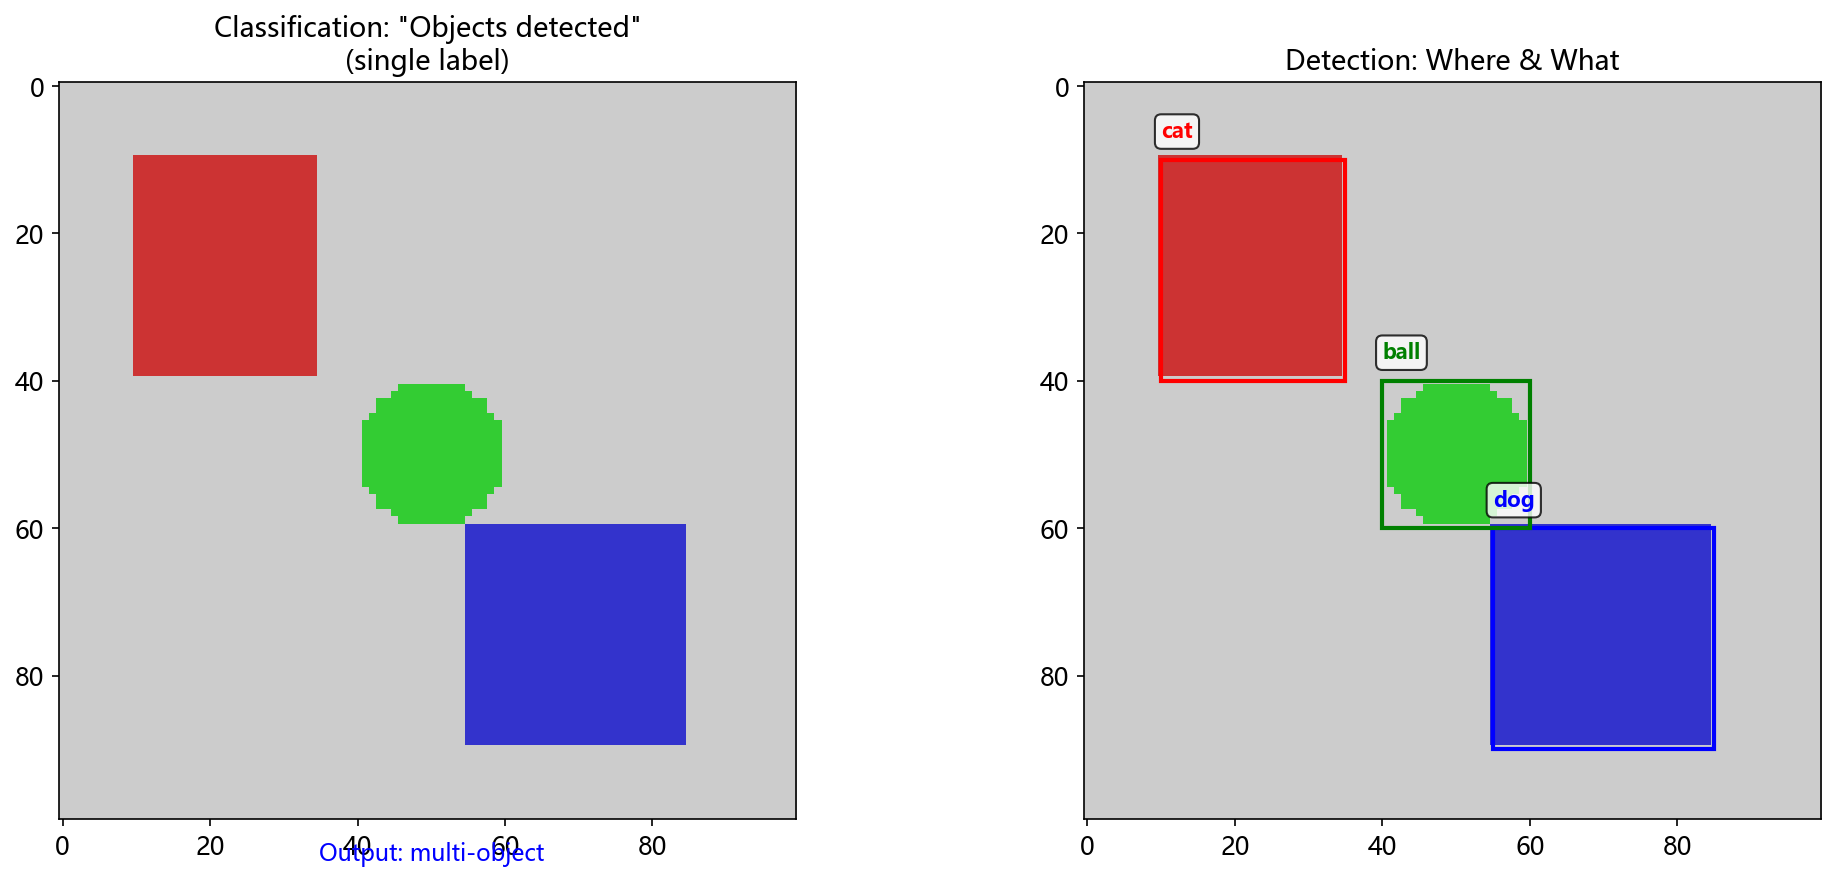

In [4]:
# Visualize: Classification vs Detection
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create a synthetic "image" with objects
img = np.ones((100, 100, 3)) * 0.8
# Object 1: red rectangle (top-left)
img[10:40, 10:35, 0] = 0.8; img[10:40, 10:35, 1] = 0.2; img[10:40, 10:35, 2] = 0.2
# Object 2: blue rectangle (bottom-right)
img[60:90, 55:85, 0] = 0.2; img[60:90, 55:85, 1] = 0.2; img[60:90, 55:85, 2] = 0.8
# Object 3: green circle (center)
for i in range(100):
    for j in range(100):
        if (i-50)**2 + (j-50)**2 < 100:
            img[i, j, 0] = 0.2; img[i, j, 1] = 0.8; img[i, j, 2] = 0.2

# Classification view
axes[0].imshow(img)
axes[0].set_title('Classification: "Objects detected"\n(single label)', fontsize=13)
axes[0].text(50, 105, 'Output: multi-object', ha='center', fontsize=11, color='blue')

# Detection view
axes[1].imshow(img)
axes[1].set_title('Detection: Where & What', fontsize=13)
# Ground truth boxes
gt_boxes = [
    (10, 10, 35, 40, 'cat'),
    (55, 60, 85, 90, 'dog'),
    (40, 40, 60, 60, 'ball'),
]
colors = ['red', 'blue', 'green']
for (x1, y1, x2, y2, label), color in zip(gt_boxes, colors):
    rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor='none')
    axes[1].add_patch(rect)
    axes[1].text(x1, y1-3, label, color=color, fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('nb8_detection_vs_classification.png', dpi=150)
plt.show()
print("Figure saved: nb8_detection_vs_classification.png")
print("\nClassification: What is in the image?")
print("Detection: What is in the image AND where is each object?")


## 1.2 R-CNN系列: 两阶段检测的演进

### R-CNN (2014, Girshick et al.)

**R-CNN = Regions + CNN**

流程:
1. **Selective Search**: 生成~2000个候选区域 (region proposals)
2. **CNN特征提取**: 对每个候选区域, 用CNN提取特征
3. **SVM分类**: 对每个类别用SVM分类
4. **BBox回归**: 微调边界框位置

**问题**: 每个候选区域都要过一次CNN, 速度极慢 (~47s/image)

### Fast R-CNN (2015)

改进: **共享卷积计算**
- 整张图过一次CNN → 得到特征图
- 候选区域映射到特征图上 → RoI Pooling
- 只对RoI做FC层分类和回归

**速度提升**: ~0.3s/image (快100倍)

### Faster R-CNN (2015)

改进: **RPN (Region Proposal Network)**
- 用网络代替Selective Search生成候选区域
- Anchor boxes: 预设不同尺度和比例的参考框
- RPN预测anchor的物体性 (objectness) 和位置修正

**速度**: ~0.2s/image (接近实时)

### 演进总结

| 版本 | 候选区域 | 特征提取 | 速度 |
|------|---------|---------|------|
| R-CNN | Selective Search | 逐区域CNN | 47s |
| Fast R-CNN | Selective Search | 共享CNN | 0.3s |
| Faster R-CNN | RPN | 共享CNN | 0.2s |


Figure saved: nb8_rcnn_pipeline.png


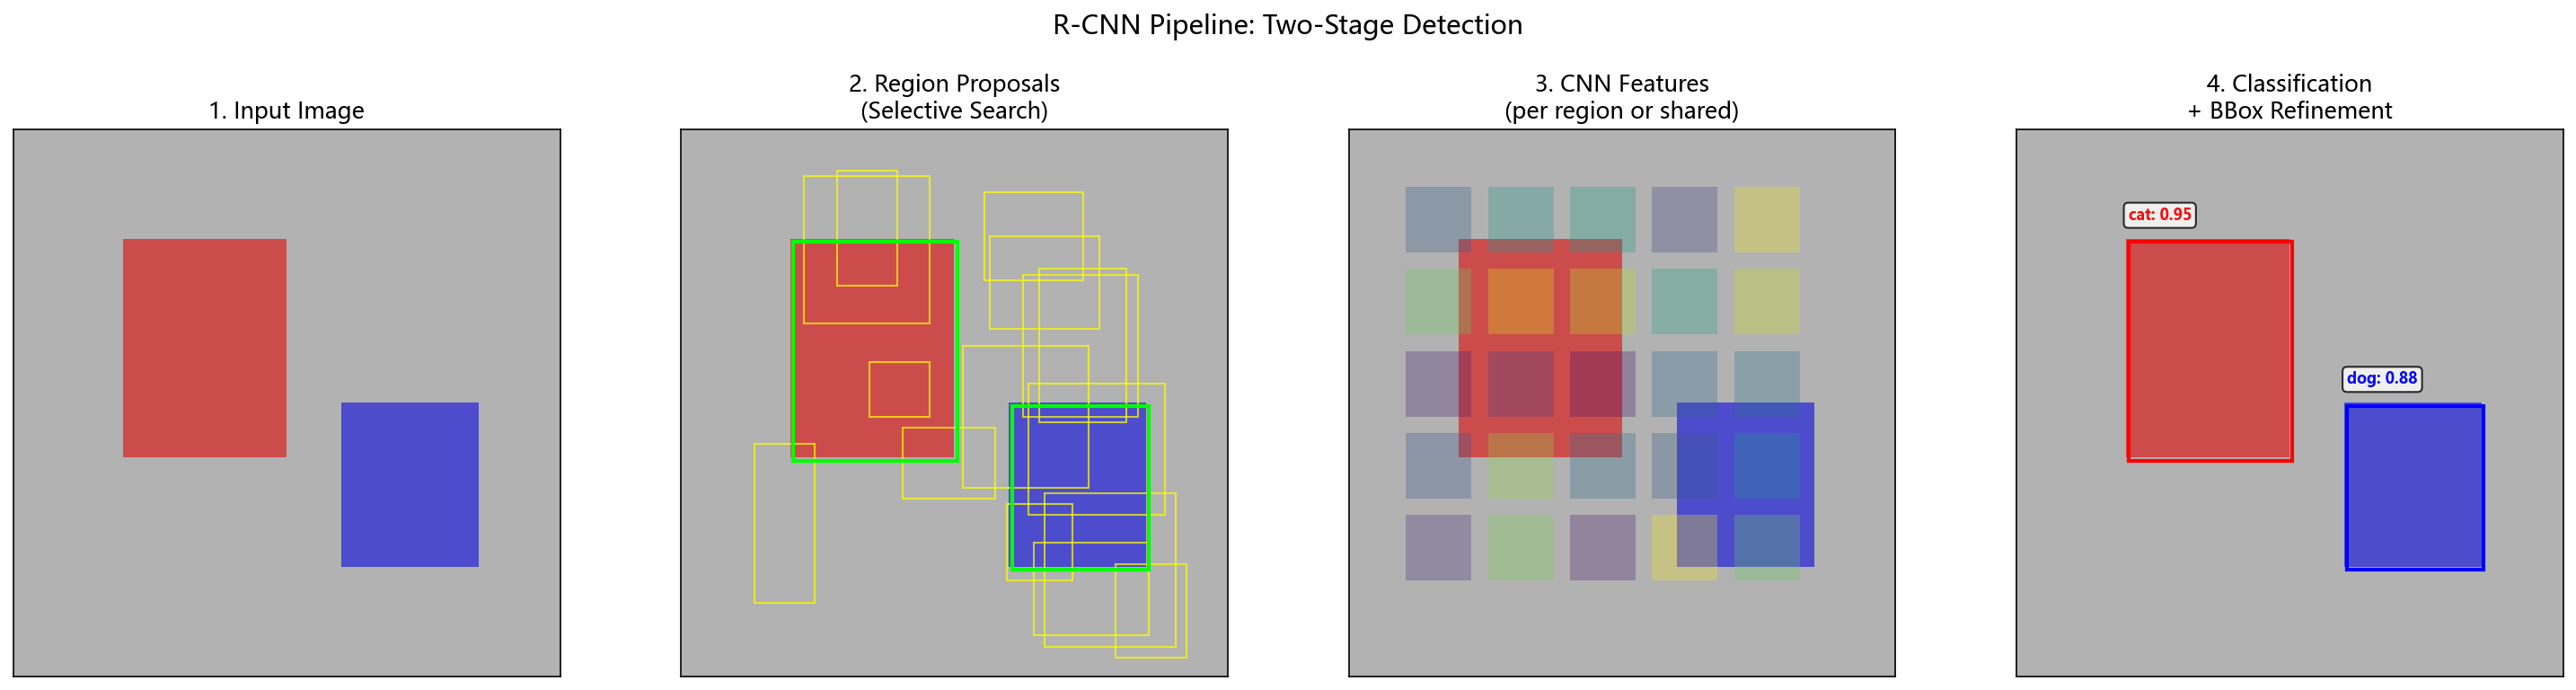

In [6]:
# Visualize R-CNN pipeline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Step 1: Input image
np.random.seed(42)
img = np.ones((100, 100, 3)) * 0.7
img[20:60, 20:50] = [0.8, 0.3, 0.3]  # red object
img[50:80, 60:85] = [0.3, 0.3, 0.8]  # blue object
axes[0].imshow(img)
axes[0].set_title('1. Input Image', fontsize=12)

# Step 2: Region proposals (SS)
axes[1].imshow(img)
# Draw many random proposal boxes
for _ in range(15):
    x = np.random.randint(5, 80)
    y = np.random.randint(5, 80)
    w = np.random.randint(10, 30)
    h = np.random.randint(10, 30)
    rect = Rectangle((x, y), w, h, linewidth=1, edgecolor='yellow', facecolor='none', alpha=0.7)
    axes[1].add_patch(rect)
# Draw good proposals
for (x1, y1, x2, y2) in [(20, 20, 50, 60), (60, 50, 85, 80)]:
    rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='lime', facecolor='none')
    axes[1].add_patch(rect)
axes[1].set_title('2. Region Proposals\n(Selective Search)', fontsize=12)

# Step 3: CNN feature extraction
axes[2].imshow(img)
# Draw CNN features as abstract representation
for i in range(5):
    for j in range(5):
        axes[2].add_patch(Rectangle((j*15+10, i*15+10), 12, 12, facecolor=plt.cm.viridis(np.random.rand()), alpha=0.3))
axes[2].set_title('3. CNN Features\n(per region or shared)', fontsize=12)

# Step 4: Classification + BBox regression
axes[3].imshow(img)
for (x1, y1, x2, y2, label, color) in [(20, 20, 50, 60, 'cat: 0.95', 'red'),
                                        (60, 50, 85, 80, 'dog: 0.88', 'blue')]:
    rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor='none')
    axes[3].add_patch(rect)
    axes[3].text(x1, y1-4, label, color=color, fontsize=8, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[3].set_title('4. Classification\n+ BBox Refinement', fontsize=12)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('R-CNN Pipeline: Two-Stage Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb8_rcnn_pipeline.png', dpi=150)
plt.show()
print("Figure saved: nb8_rcnn_pipeline.png")


## 1.3 YOLO: 单次检测的革命

### YOLO = You Only Look Once (2016, Redmon et al.)

核心思想: **将检测视为回归问题, 一次前向传播完成所有预测。**

### YOLO流程

1. **网格划分**: 将图像分为 $S \times S$ 网格
2. **责任分配**: 物体中心落入哪个格子, 该格子负责检测
3. **预测**: 每个格子预测 $B$ 个bbox和 $C$ 个类别概率
4. **输出**: $S \times S \times (B \times 5 + C)$ 的张量

### YOLOv1输出

- $S=7, B=2, C=20$ (PASCAL VOC)
- 输出: $7 \times 7 \times (2 \times 5 + 20) = 7 \times 7 \times 30$
- 每个bbox: $(x, y, w, h, confidence)$
  - $(x, y)$: bbox中心相对于格子
  - $(w, h)$: 宽高相对于整图
  - $confidence = P(obj) \times IoU(pred, gt)$

### YOLO的优势
1. **速度快**: 45 FPS (YOLOv1), 后续版本更快
2. **全局推理**: 看整张图, 减少背景误检
3. **端到端**: 一个网络完成所有工作

### YOLO的劣势
1. **小物体**: 网格分辨率限制小物体检测
2. **密集场景**: 相邻物体可能竞争同一格子
3. **泛化**: 对新尺度/比例泛化较弱


Figure saved: nb8_yolo_grid.png

Key insight: Each object is assigned to ONE grid cell (where its center falls)
Finer grid = better spatial resolution but more computation


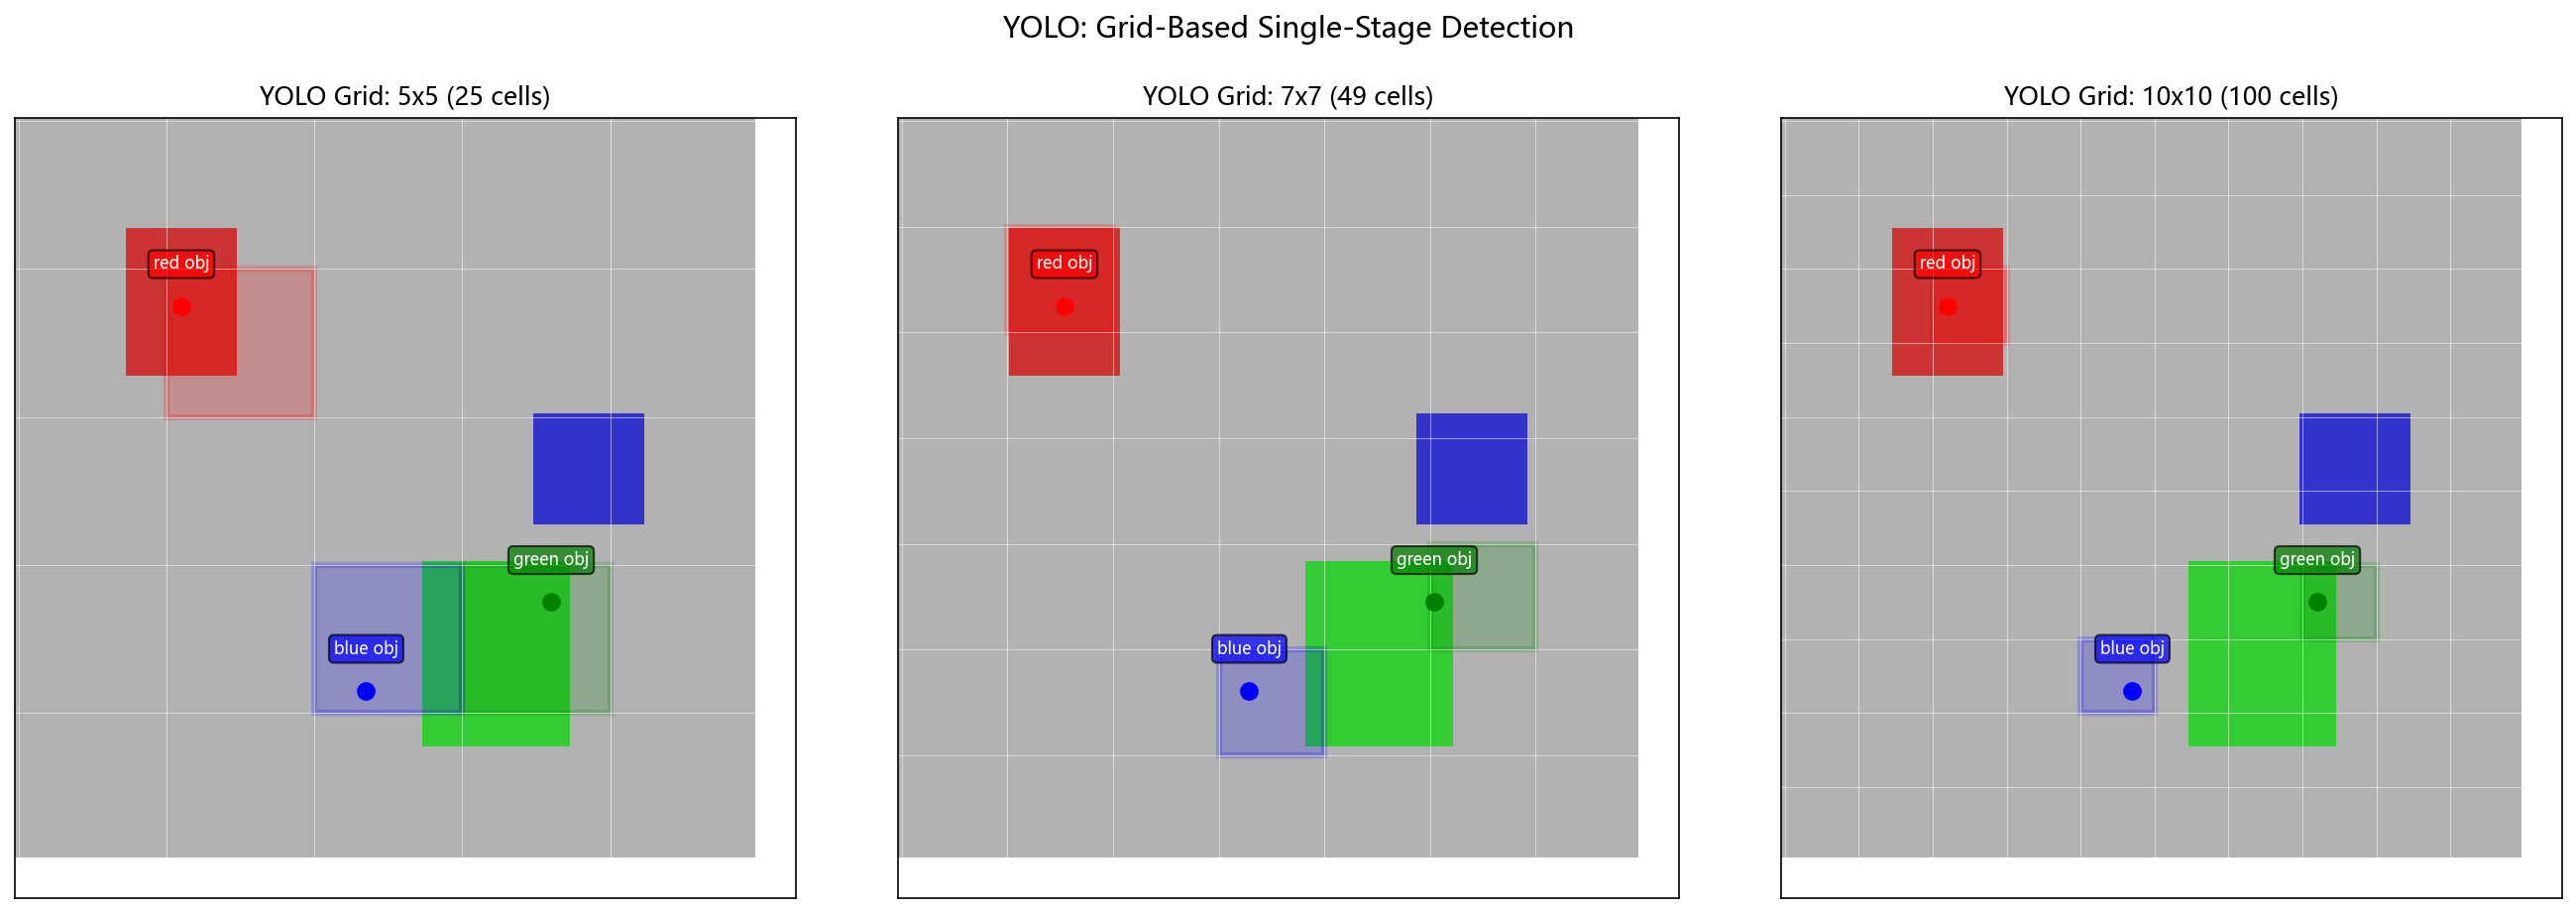

In [8]:
# Visualize YOLO grid detection
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Create image with objects
img = np.ones((100, 100, 3)) * 0.7
img[15:35, 15:30] = [0.8, 0.2, 0.2]  # red object (center at ~22, 25)
img[60:85, 55:75] = [0.2, 0.8, 0.2]  # green object (center at ~72, 65)
img[40:55, 70:85] = [0.2, 0.2, 0.8]  # blue object (center at ~47, 77)

# Grid sizes to compare
grid_sizes = [5, 7, 10]

for idx, S in enumerate(grid_sizes):
    axes[idx].imshow(img)
    
    # Draw grid
    cell_size = 100 / S
    for i in range(S + 1):
        axes[idx].axhline(i * cell_size, color='white', linewidth=0.5, alpha=0.5)
        axes[idx].axvline(i * cell_size, color='white', linewidth=0.5, alpha=0.5)
    
    # Highlight responsible cells (where object centers fall)
    objects = [(22, 25), (72, 65), (47, 77)]
    obj_labels = ['red obj', 'green obj', 'blue obj']
    obj_colors = ['red', 'green', 'blue']
    
    for (cx, cy, label, color) in [(o[0], o[1], l, c) for o, l, c in zip(objects, obj_labels, obj_colors)]:
        grid_x = int(cx / cell_size)
        grid_y = int(cy / cell_size)
        rect = Rectangle((grid_x * cell_size, grid_y * cell_size), cell_size, cell_size,
                         linewidth=3, edgecolor=color, facecolor=color, alpha=0.2)
        axes[idx].add_patch(rect)
        axes[idx].plot(cx, cy, 'o', color=color, markersize=8)
        axes[idx].text(cx, cy - 5, label, color='white', fontsize=8, ha='center',
                      bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))
    
    axes[idx].set_title(f'YOLO Grid: {S}x{S} ({S*S} cells)', fontsize=12)
    axes[idx].set_xticks([]); axes[idx].set_yticks([])

plt.suptitle('YOLO: Grid-Based Single-Stage Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb8_yolo_grid.png', dpi=150)
plt.show()
print("Figure saved: nb8_yolo_grid.png")
print("\nKey insight: Each object is assigned to ONE grid cell (where its center falls)")
print("Finer grid = better spatial resolution but more computation")


## 1.4 Anchor Boxes: 预设参考框

### 为什么需要Anchor?

- 物体有不同的大小和长宽比
- 直接回归bbox参数 (x, y, w, h) 需要学习绝对位置
- **Anchor**: 预设一组参考框, 网络只需学习相对anchor的偏移

### Anchor生成

对于特征图上的每个位置, 生成 $k$ 个anchor:
- $k = \text{len(scales)} \times \text{len(ratios)}$
- 例如: 3 scales $	imes$ 3 ratios = 9 anchors per location

### 常用Anchor设置 (Faster R-CNN)
- Scales: $128^2, 256^2, 512^2$
- Ratios: 1:1, 1:2, 2:1
- 每个位置: 9个anchor
- 特征图 $50 \times 50$: 共 $50 \times 50 \times 9 = 22500$ 个anchor

### YOLO的Anchor (YOLOv2+)
- YOLO使用k-means聚类在训练集上自动确定anchor尺寸
- 每个尺度使用不同大小的anchor


Figure saved: nb8_anchor_boxes.png

Anchors cover different object sizes and shapes at each location


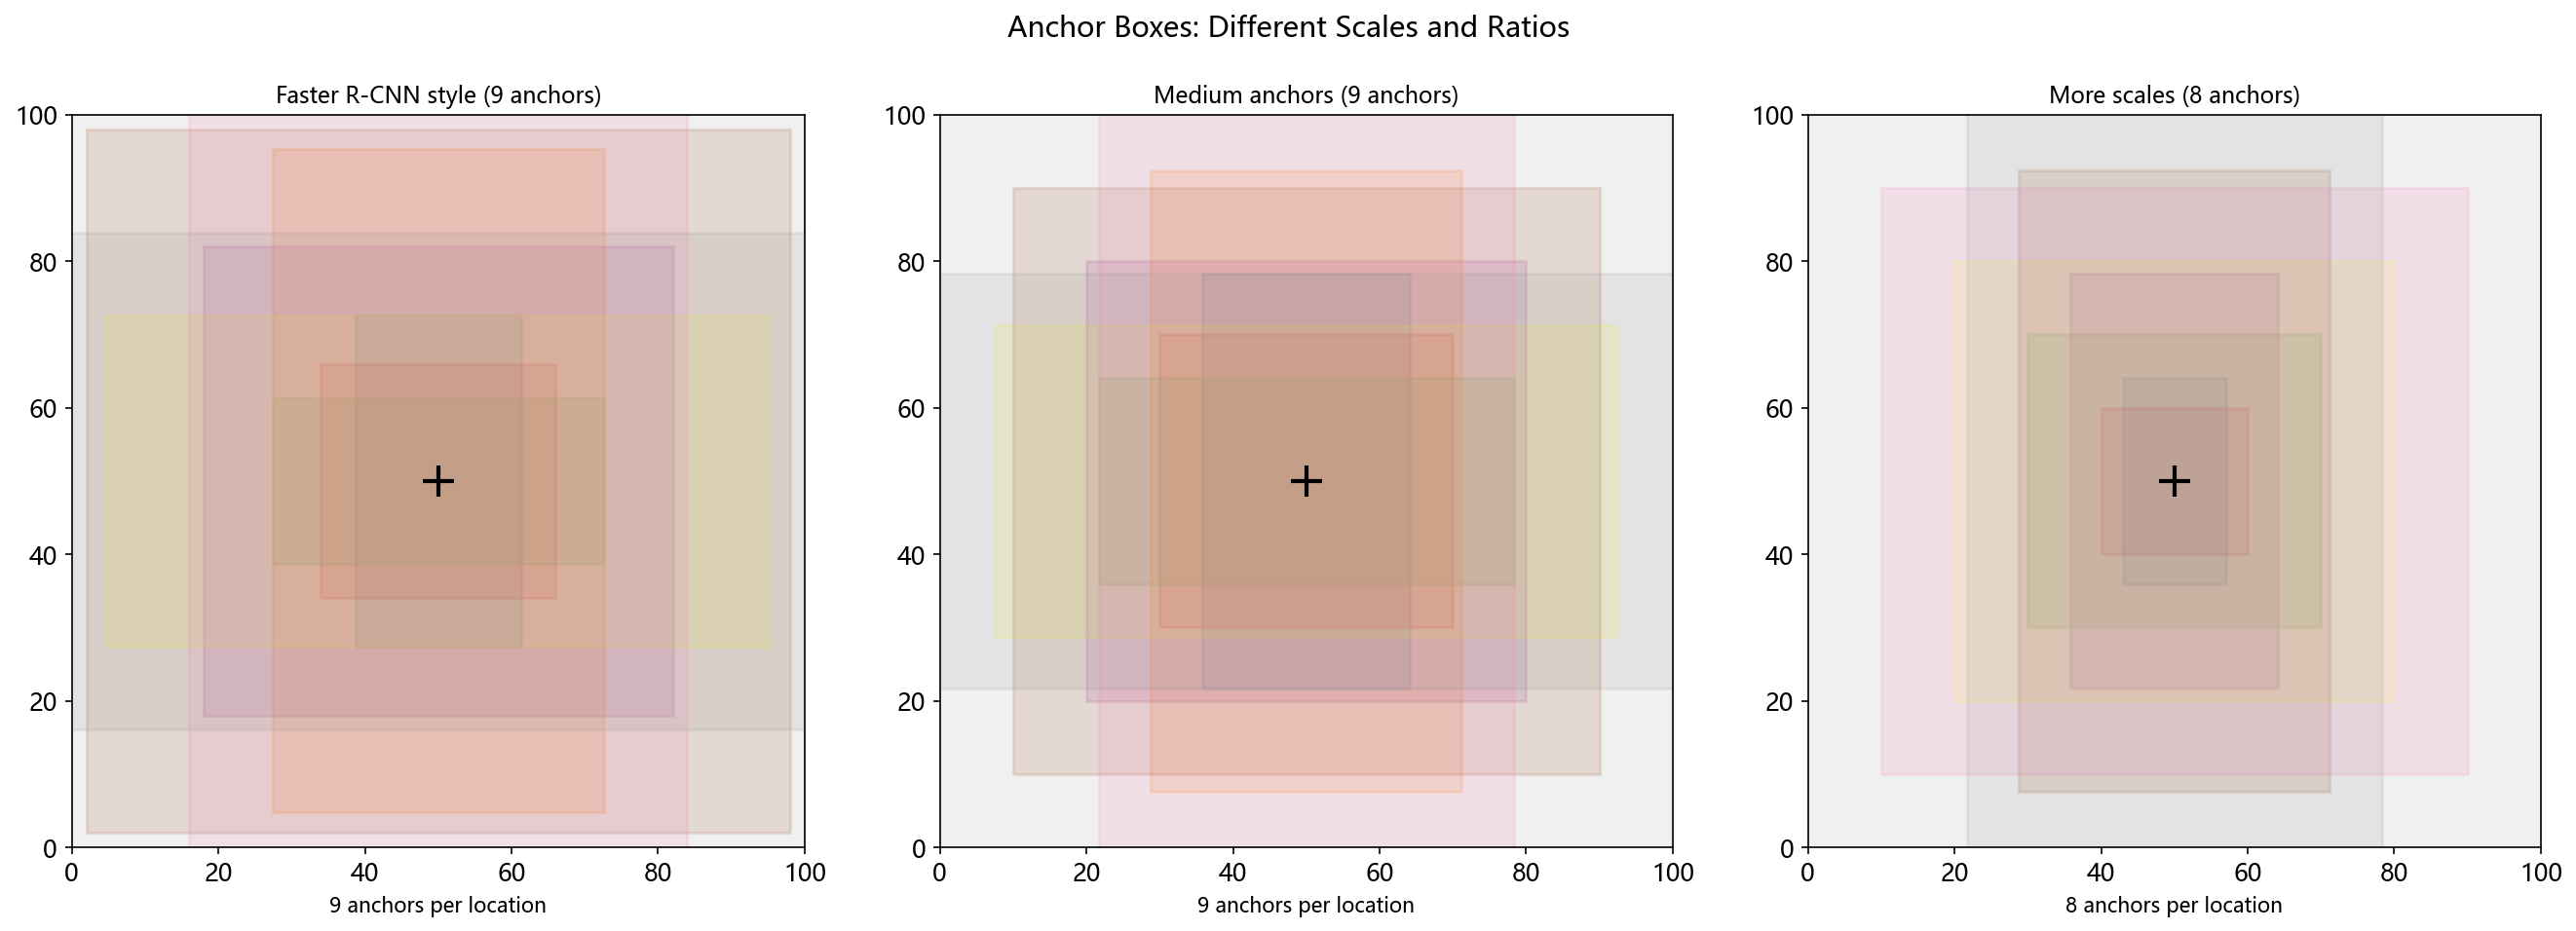

In [10]:
# Visualize anchor boxes
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def generate_anchors(center_x, center_y, sizes, ratios):
    """Generate anchor boxes at a given center point.
    sizes: list of base sizes
    ratios: list of width/height ratios
    Returns: list of (x1, y1, x2, y2)
    """
    anchors = []
    for size in sizes:
        for ratio in ratios:
            h = size / np.sqrt(ratio)
            w = size * np.sqrt(ratio)
            x1 = center_x - w / 2
            y1 = center_y - h / 2
            x2 = center_x + w / 2
            y2 = center_y + h / 2
            anchors.append((x1, y1, x2, y2))
    return anchors

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Different anchor configurations
configs = [
    {'sizes': [32, 64, 96], 'ratios': [1.0, 0.5, 2.0], 'title': 'Faster R-CNN style (9 anchors)'},
    {'sizes': [40, 60, 80], 'ratios': [1.0, 0.5, 2.0], 'title': 'Medium anchors (9 anchors)'},
    {'sizes': [20, 40, 60, 80], 'ratios': [1.0, 0.5], 'title': 'More scales (8 anchors)'},
]

center_x, center_y = 50, 50

for idx, cfg in enumerate(configs):
    axes[idx].set_xlim(0, 100)
    axes[idx].set_ylim(0, 100)
    axes[idx].set_aspect('equal')
    axes[idx].set_facecolor('#f0f0f0')
    
    anchors = generate_anchors(center_x, center_y, cfg['sizes'], cfg['ratios'])
    colors = plt.cm.Set1(np.linspace(0, 1, len(anchors)))
    
    for i, (x1, y1, x2, y2) in enumerate(anchors):
        w = x2 - x1
        h = y2 - y1
        rect = Rectangle((x1, y1), w, h, linewidth=1.5, edgecolor=colors[i], facecolor=colors[i], alpha=0.15)
        axes[idx].add_patch(rect)
    
    axes[idx].plot(center_x, center_y, 'k+', markersize=15, markeredgewidth=2)
    axes[idx].set_title(cfg['title'], fontsize=11)
    axes[idx].set_xlabel(f'{len(anchors)} anchors per location', fontsize=10)

plt.suptitle('Anchor Boxes: Different Scales and Ratios', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb8_anchor_boxes.png', dpi=150)
plt.show()
print("Figure saved: nb8_anchor_boxes.png")
print("\nAnchors cover different object sizes and shapes at each location")


## 1.5 IoU (交并比): 评估框重合度

### 定义

$$IoU = \frac{\text{Intersection Area}}{\text{Union Area}} = \frac{|A \cap B|}{|A \cup B|}$$

### 直觉

IoU衡量两个边界框的重合程度:
- $IoU = 1.0$: 完全重合
- $IoU = 0.5$: 部分重合 (常用阈值)
- $IoU = 0.0$: 完全不重合

### IoU的用途

1. **训练时**: 匹配anchor与ground truth (IoU > 阈值 = 正样本)
2. **评估时**: 判断检测结果是否正确 (IoU > 0.5 = TP)
3. **NMS**: 合并重复检测 (IoU > 阈值 = 重复)
4. **mAP**: 计算平均精度 (不同IoU阈值下的精度)

### IoU计算步骤

1. 计算交集区域: $A \cap B$
2. 计算并集区域: $A \cup B = |A| + |B| - |A \cap B|$
3. 比值: $IoU = \frac{|A \cap B|}{|A \cup B|}$


Figure saved: nb8_iou_visualization.png


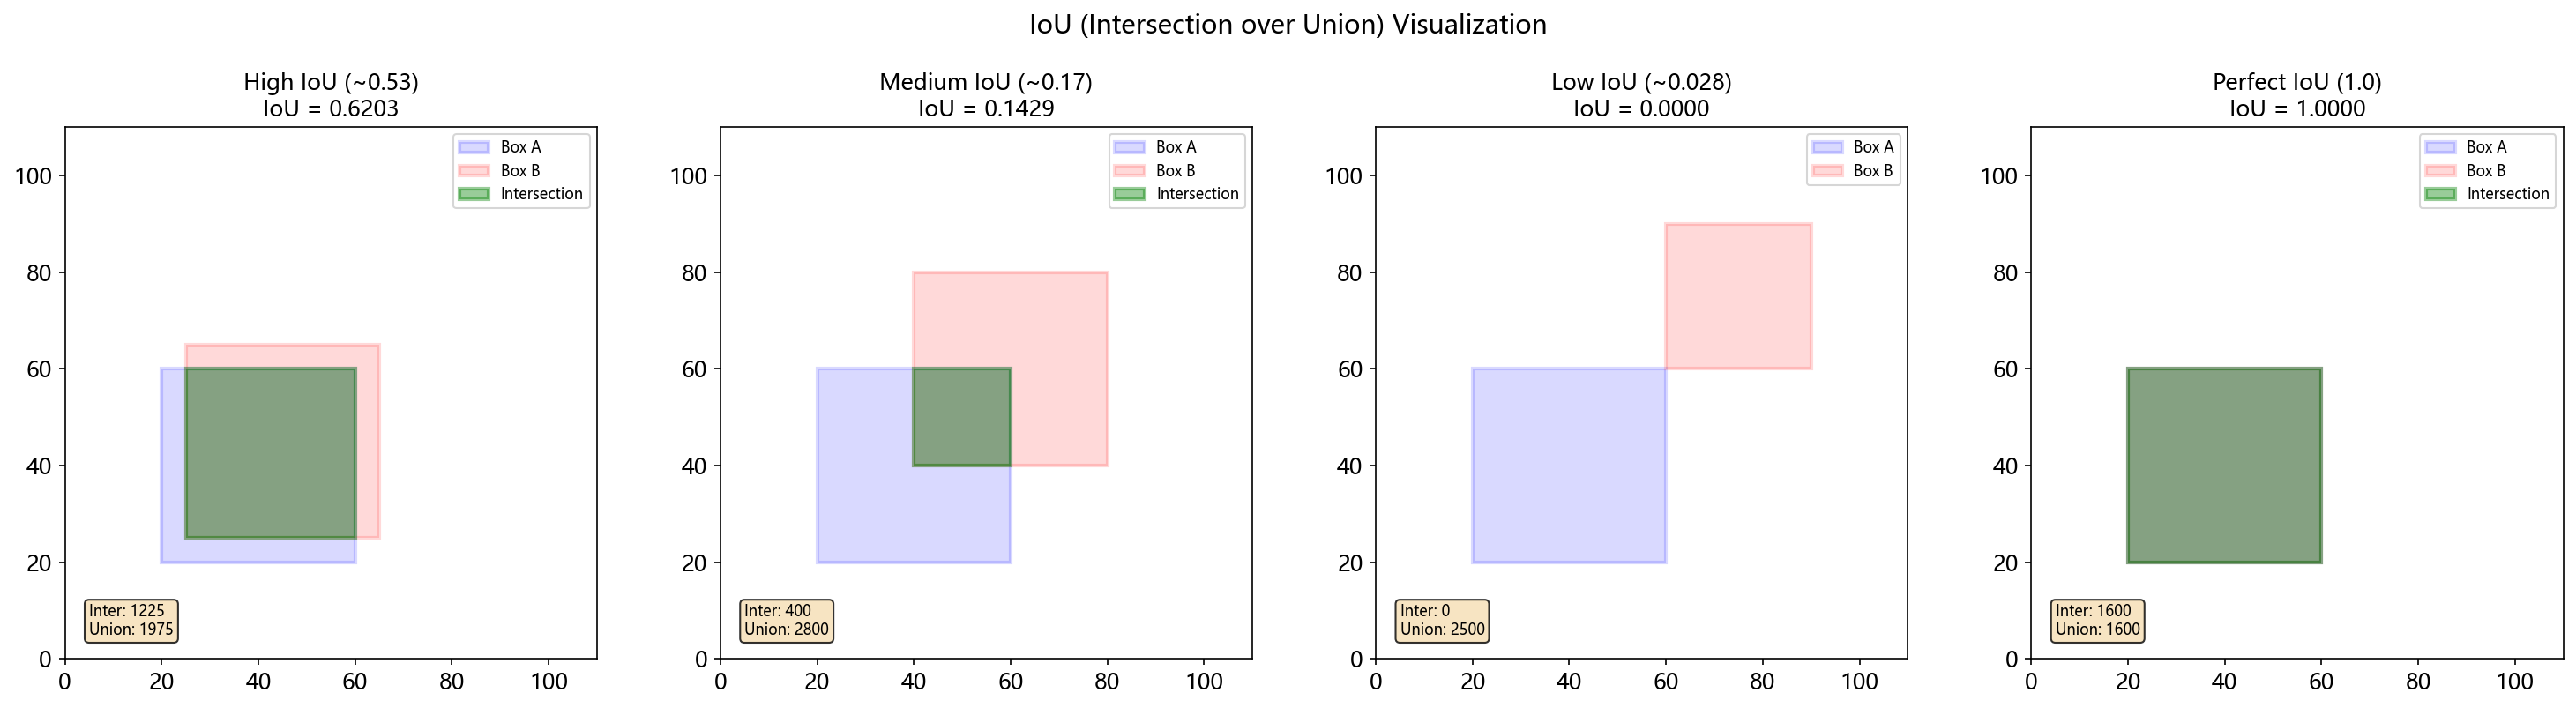

In [12]:
# Visualize IoU calculation
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon
import matplotlib.patches as mpatches

def compute_iou(box1, box2):
    """Compute IoU between two boxes.
    box format: [x1, y1, x2, y2]
    """
    # Intersection
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h
    
    # Union
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = area1 + area2 - inter_area
    
    iou = inter_area / union_area if union_area > 0 else 0
    return iou, (x1, y1, x2, y2), inter_area, area1, area2, union_area

# Create different overlap scenarios
box_a = [20, 20, 60, 60]
scenarios = [
    (box_a, [25, 25, 65, 65], 'High IoU (~0.53)'),
    (box_a, [40, 40, 80, 80], 'Medium IoU (~0.17)'),
    (box_a, [60, 60, 90, 90], 'Low IoU (~0.028)'),
    (box_a, [20, 20, 60, 60], 'Perfect IoU (1.0)'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, (b1, b2, title) in enumerate(scenarios):
    iou, inter_box, inter_area, a1, a2, union = compute_iou(b1, b2)
    
    axes[idx].set_xlim(0, 110)
    axes[idx].set_ylim(0, 110)
    axes[idx].set_aspect('equal')
    
    # Draw box A
    rect_a = Rectangle((b1[0], b1[1]), b1[2]-b1[0], b1[3]-b1[1], 
                        linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.15, label='Box A')
    axes[idx].add_patch(rect_a)
    
    # Draw box B
    rect_b = Rectangle((b2[0], b2[1]), b2[2]-b2[0], b2[3]-b2[1],
                        linewidth=2, edgecolor='red', facecolor='red', alpha=0.15, label='Box B')
    axes[idx].add_patch(rect_b)
    
    # Draw intersection
    if inter_area > 0:
        rect_inter = Rectangle((inter_box[0], inter_box[1]), inter_box[2]-inter_box[0], inter_box[3]-inter_box[1],
                                linewidth=2, edgecolor='green', facecolor='green', alpha=0.4, label='Intersection')
        axes[idx].add_patch(rect_inter)
    
    axes[idx].set_title(f'{title}\nIoU = {iou:.4f}', fontsize=12)
    axes[idx].legend(fontsize=8, loc='upper right')
    axes[idx].text(5, 5, f'Inter: {inter_area:.0f}\nUnion: {union:.0f}', fontsize=8,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('IoU (Intersection over Union) Visualization', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb8_iou_visualization.png', dpi=150)
plt.show()
print("Figure saved: nb8_iou_visualization.png")


## 1.6 NMS (非极大值抑制): 去除重复检测

### 问题

在目标检测中, 同一个物体可能被检测多次:
- R-CNN: 多个候选区域可能覆盖同一物体
- YOLO: 相邻格子可能预测同一物体

### NMS流程

1. 按置信度降序排列所有检测框
2. 取置信度最高的框, 加入"保留"列表
3. 计算该框与其余所有框的IoU
4. 删除IoU > 阈值 (如0.5) 的框 (重复检测)
5. 重复步骤2-4, 直到所有框被处理或删除

### Soft-NMS (改进)

不直接删除, 而是降低重叠框的分数:
$$s_i = s_i \cdot f(iou(b_{best}, b_i))$$

其中 $f$ 可以是线性衰减或高斯衰减。

### 关键参数
- **IoU阈值**: 越高, 保留的框越多 (可能漏检)
- **置信度阈值**: 越低, 参与NMS的框越多 (可能误检)


Figure saved: nb8_nms_process.png

Before NMS: 7 boxes
After NMS: 3 boxes (kept indices: [np.int64(0), np.int64(4), np.int64(6)])


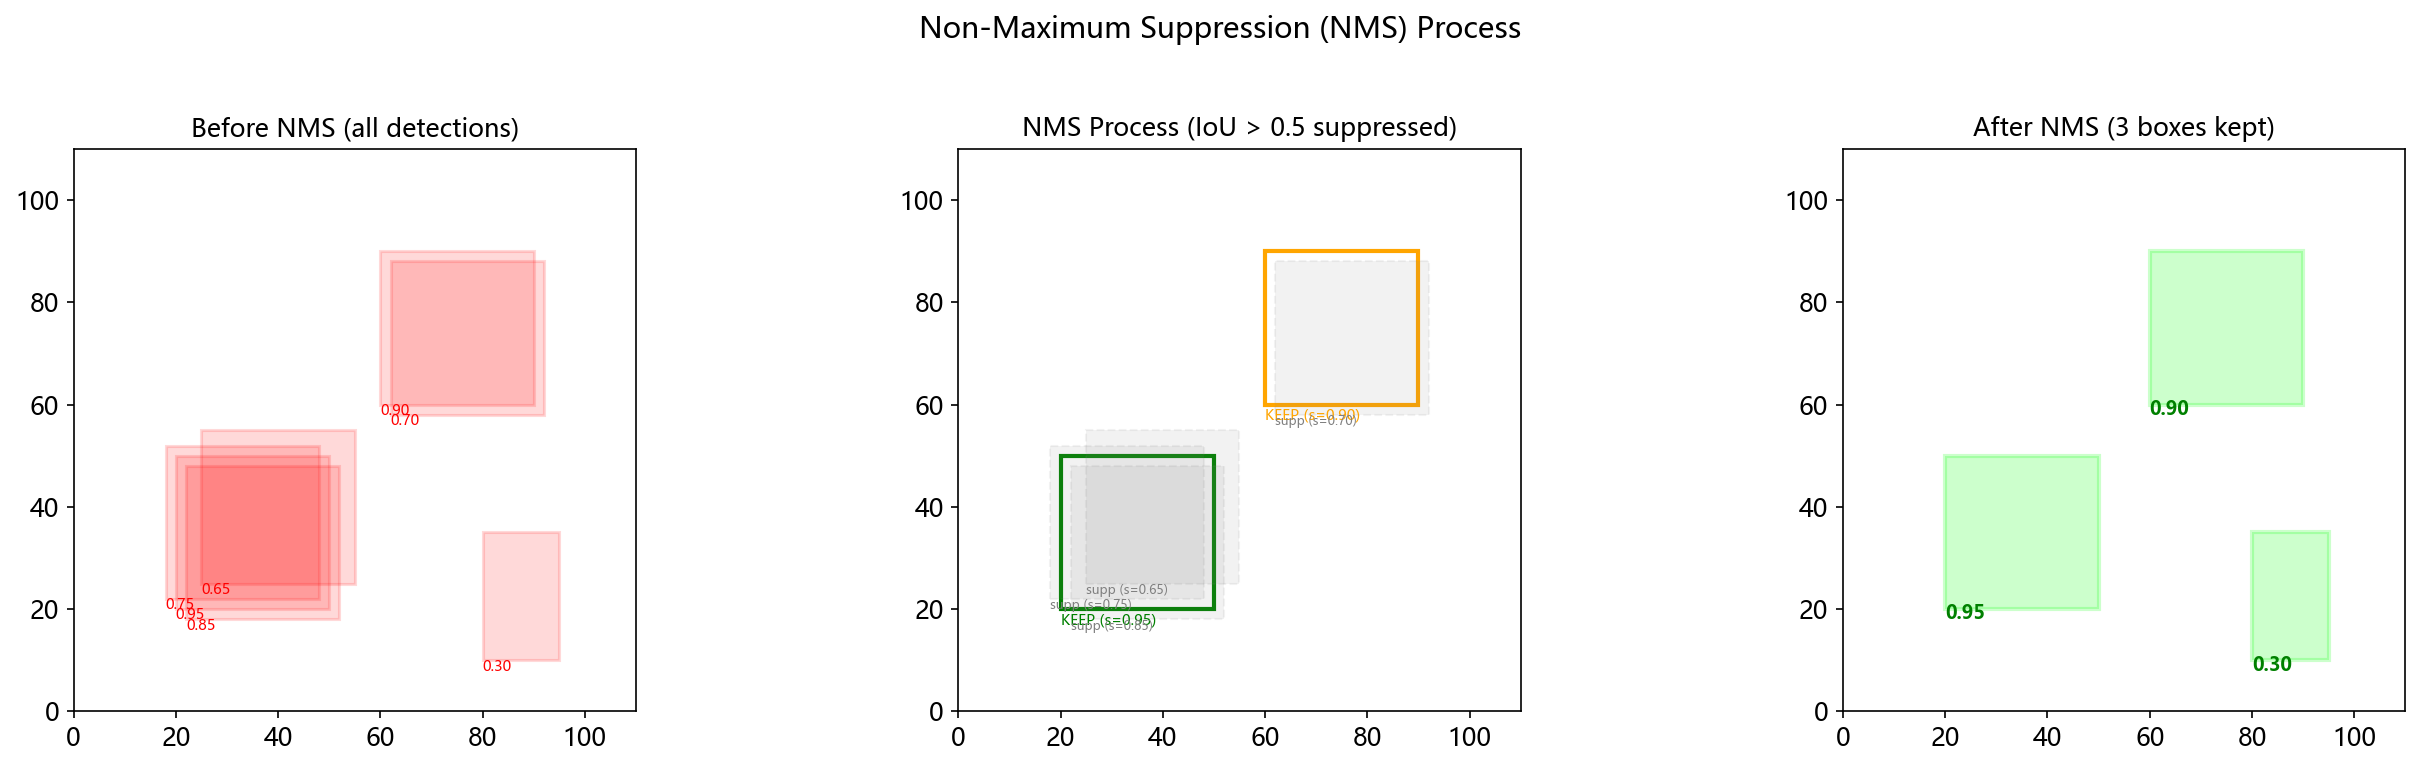

In [14]:
# Visualize NMS process
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

np.random.seed(42)

# Simulate detection results: many overlapping boxes
boxes = np.array([
    [20, 20, 50, 50],   # ground truth area
    [22, 18, 52, 48],   # overlapping
    [18, 22, 48, 52],   # overlapping
    [25, 25, 55, 55],   # overlapping
    [60, 60, 90, 90],   # separate object
    [62, 58, 92, 88],   # overlapping with above
    [80, 10, 95, 35],   # separate, low confidence
])
scores = np.array([0.95, 0.85, 0.75, 0.65, 0.90, 0.70, 0.30])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Before NMS
axes[0].set_xlim(0, 110); axes[0].set_ylim(0, 110); axes[0].set_aspect('equal')
axes[0].set_title('Before NMS (all detections)', fontsize=12)
for box, score in zip(boxes, scores):
    rect = Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                      linewidth=1.5, edgecolor='red', facecolor='red', alpha=0.15)
    axes[0].add_patch(rect)
    axes[0].text(box[0], box[1]-2, f'{score:.2f}', fontsize=7, color='red')

# NMS process visualization
def nms(boxes, scores, iou_threshold=0.5):
    """NMS implementation."""
    order = scores.argsort()[::-1]
    keep = []
    suppress_history = []
    
    while order.size > 0:
        i = order[0]
        keep.append(i)
        if order.size == 1:
            break
        rest = order[1:]
        ious = np.array([compute_iou(boxes[i], boxes[j])[0] for j in rest])
        suppressed = rest[ious >= iou_threshold]
        suppress_history.append((i, suppressed.tolist()))
        order = rest[ious < iou_threshold]
    
    return keep, suppress_history

keep, history = nms(boxes, scores, iou_threshold=0.5)

# During NMS (step by step)
axes[1].set_xlim(0, 110); axes[1].set_ylim(0, 110); axes[1].set_aspect('equal')
axes[1].set_title('NMS Process (IoU > 0.5 suppressed)', fontsize=12)
step_colors = ['green', 'orange', 'purple']
for step, (kept_idx, supp_idxs) in enumerate(history):
    color = step_colors[step % len(step_colors)]
    box = boxes[kept_idx]
    rect = Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                      linewidth=2, edgecolor=color, facecolor='none')
    axes[1].add_patch(rect)
    axes[1].text(box[0], box[1]-3, f'KEEP (s={scores[kept_idx]:.2f})', fontsize=7, color=color)
    for sidx in supp_idxs:
        box = boxes[sidx]
        rect = Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                          linewidth=1, edgecolor='gray', facecolor='gray', alpha=0.1, linestyle='--')
        axes[1].add_patch(rect)
        axes[1].text(box[0], box[1]-2, f'supp (s={scores[sidx]:.2f})', fontsize=6, color='gray')

# After NMS
axes[2].set_xlim(0, 110); axes[2].set_ylim(0, 110); axes[2].set_aspect('equal')
axes[2].set_title(f'After NMS ({len(keep)} boxes kept)', fontsize=12)
for idx in keep:
    box = boxes[idx]
    rect = Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                      linewidth=2, edgecolor='lime', facecolor='lime', alpha=0.2)
    axes[2].add_patch(rect)
    axes[2].text(box[0], box[1]-2, f'{scores[idx]:.2f}', fontsize=9, color='green', fontweight='bold')

plt.suptitle('Non-Maximum Suppression (NMS) Process', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb8_nms_process.png', dpi=150)
plt.show()
print("Figure saved: nb8_nms_process.png")
print(f"\nBefore NMS: {len(boxes)} boxes")
print(f"After NMS: {len(keep)} boxes (kept indices: {keep})")


---
# Part 2: 手动计算

## 2.1 IoU手动计算

### 给定两个边界框 (格式: [x1, y1, x2, y2])

$$A = [10, 10, 50, 50], \quad B = [30, 30, 70, 70]$$

### Step 1: 计算交集

$$x_1 = \max(10, 30) = 30$$
$$y_1 = \max(10, 30) = 30$$
$$x_2 = \min(50, 70) = 50$$
$$y_2 = \min(50, 70) = 50$$

交集面积 = $(50-30) \times (50-30) = 20 \times 20 = 400$

### Step 2: 计算各自面积

$$|A| = (50-10) \times (50-10) = 40 \times 40 = 1600$$
$$|B| = (70-30) \times (70-30) = 40 \times 40 = 1600$$

### Step 3: 计算并集

$$|A \cup B| = |A| + |B| - |A \cap B| = 1600 + 1600 - 400 = 2800$$

### Step 4: 计算IoU

$$IoU = \frac{400}{2800} = \frac{1}{7} \approx 0.143$$


In [16]:
# IoU manual calculation (step by step)
import numpy as np

print("=== IoU Manual Calculation ===")
box_a = [10, 10, 50, 50]
box_b = [30, 30, 70, 70]

print(f"Box A: {box_a} -> width={box_a[2]-box_a[0]}, height={box_a[3]-box_a[1]}")
print(f"Box B: {box_b} -> width={box_b[2]-box_b[0]}, height={box_b[3]-box_b[1]}")

# Step 1: Intersection
x1 = max(box_a[0], box_b[0])
y1 = max(box_a[1], box_b[1])
x2 = min(box_a[2], box_b[2])
y2 = min(box_a[3], box_b[3])

print(f"\nStep 1 - Intersection:")
print(f"  x1 = max({box_a[0]}, {box_b[0]}) = {x1}")
print(f"  y1 = max({box_a[1]}, {box_b[1]}) = {y1}")
print(f"  x2 = min({box_a[2]}, {box_b[2]}) = {x2}")
print(f"  y2 = min({box_a[3]}, {box_b[3]}) = {y2}")

inter_w = max(0, x2 - x1)
inter_h = max(0, y2 - y1)
inter_area = inter_w * inter_h
print(f"  Intersection area = {inter_w} x {inter_h} = {inter_area}")

# Step 2: Individual areas
area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
print(f"\nStep 2 - Areas:")
print(f"  Area A = ({box_a[2]}-{box_a[0]}) x ({box_a[3]}-{box_a[1]}) = {area_a}")
print(f"  Area B = ({box_b[2]}-{box_b[0]}) x ({box_b[3]}-{box_b[1]}) = {area_b}")

# Step 3: Union
union_area = area_a + area_b - inter_area
print(f"\nStep 3 - Union:")
print(f"  Union = {area_a} + {area_b} - {inter_area} = {union_area}")

# Step 4: IoU
iou = inter_area / union_area
print(f"\nStep 4 - IoU:")
print(f"  IoU = {inter_area} / {union_area} = {iou:.6f}")
print(f"  IoU = {iou:.4f} (4 decimal places)")

# Verify with function
iou_func, _, _, _, _, _ = compute_iou(box_a, box_b)
print(f"\nVerification (function): IoU = {iou_func:.6f}")
print(f"Match: {abs(iou - iou_func) < 1e-10}")


=== IoU Manual Calculation ===
Box A: [10, 10, 50, 50] -> width=40, height=40
Box B: [30, 30, 70, 70] -> width=40, height=40

Step 1 - Intersection:
  x1 = max(10, 30) = 30
  y1 = max(10, 30) = 30
  x2 = min(50, 70) = 50
  y2 = min(50, 70) = 50
  Intersection area = 20 x 20 = 400

Step 2 - Areas:
  Area A = (50-10) x (50-10) = 1600
  Area B = (70-30) x (70-30) = 1600

Step 3 - Union:
  Union = 1600 + 1600 - 400 = 2800

Step 4 - IoU:
  IoU = 400 / 2800 = 0.142857
  IoU = 0.1429 (4 decimal places)

Verification (function): IoU = 0.142857
Match: True


## 2.2 边界框回归手动计算

### BBox回归的目的

将预测框 $(P)$ 调整到更接近真实框 $(G)$。

### 回归参数 (相对anchor的偏移)

$$t_x = (G_x - A_x) / A_w, \quad t_y = (G_y - A_y) / A_h$$
$$t_w = \log(G_w / A_w), \quad t_h = \log(G_h / A_h)$$

其中:
- $(A_x, A_y, A_w, A_h)$: anchor框 (中心x, 中心y, 宽, 高)
- $(G_x, G_y, G_w, G_h)$: ground truth框

### 数值示例

Anchor: $A = [20, 20, 50, 50]$ → 中心 $(35, 35)$, 宽 $30$, 高 $30$
Ground Truth: $G = [25, 15, 55, 45]$ → 中心 $(40, 30)$, 宽 $30$, 高 $30$

$$t_x = (40 - 35) / 30 = 0.167$$
$$t_y = (30 - 35) / 30 = -0.167$$
$$t_w = \log(30/30) = 0$$
$$t_h = \log(30/30) = 0$$

### 从回归参数恢复框

$$G_x = A_w \cdot t_x + A_x, \quad G_y = A_h \cdot t_y + A_y$$
$$G_w = A_w \cdot e^{t_w}, \quad G_h = A_h \cdot e^{t_h}$$


In [18]:
# Bounding box regression manual calculation
import numpy as np

def xyxy_to_cxcywh(box):
    """Convert [x1,y1,x2,y2] to [cx,cy,w,h]."""
    cx = (box[0] + box[2]) / 2
    cy = (box[1] + box[3]) / 2
    w = box[2] - box[0]
    h = box[3] - box[1]
    return np.array([cx, cy, w, h])

def cxcywh_to_xyxy(box):
    """Convert [cx,cy,w,h] to [x1,y1,x2,y2]."""
    x1 = box[0] - box[2] / 2
    y1 = box[1] - box[3] / 2
    x2 = box[0] + box[2] / 2
    y2 = box[1] + box[3] / 2
    return np.array([x1, y1, x2, y2])

def encode_box(anchor, gt):
    """Encode ground truth relative to anchor."""
    a = xyxy_to_cxcywh(anchor)
    g = xyxy_to_cxcywh(gt)
    tx = (g[0] - a[0]) / a[2]
    ty = (g[1] - a[1]) / a[3]
    tw = np.log(g[2] / a[2])
    th = np.log(g[3] / a[3])
    return np.array([tx, ty, tw, th])

def decode_box(anchor, deltas):
    """Decode predicted deltas to absolute box."""
    a = xyxy_to_cxcywh(anchor)
    cx = deltas[0] * a[2] + a[0]
    cy = deltas[1] * a[3] + a[1]
    w = np.exp(deltas[2]) * a[2]
    h = np.exp(deltas[3]) * a[3]
    return cxcywh_to_xyxy(np.array([cx, cy, w, h]))

# Manual calculation
anchor = np.array([20, 20, 50, 50])  # [x1,y1,x2,y2]
gt = np.array([25, 15, 55, 45])

print("=== BBox Regression Manual Calculation ===")
print(f"Anchor (xyxy): {anchor}")
print(f"Anchor (cxcywh): {xyxy_to_cxcywh(anchor)}")
print(f"GT (xyxy): {gt}")
print(f"GT (cxcywh): {xyxy_to_cxcywh(gt)}")

deltas = encode_box(anchor, gt)
print(f"\nEncoded deltas (tx, ty, tw, th): {deltas.round(4)}")

# Verify by decoding
decoded = decode_box(anchor, deltas)
print(f"Decoded box: {decoded}")
print(f"Original GT: {gt}")
print(f"Match: {np.allclose(decoded, gt)}")

# Test with different sizes
print("\n=== Different size example ===")
anchor2 = np.array([10, 10, 30, 30])  # smaller anchor
gt2 = np.array([12, 8, 36, 28])  # slightly shifted and resized
deltas2 = encode_box(anchor2, gt2)
print(f"Anchor: {anchor2} -> cxcywh: {xyxy_to_cxcywh(anchor2)}")
print(f"GT: {gt2} -> cxcywh: {xyxy_to_cxcywh(gt2)}")
print(f"Deltas: {deltas2.round(4)}")
print(f"tw = log({xyxy_to_cxcywh(gt2)[2]}/{xyxy_to_cxcywh(anchor2)[2]}) = log({xyxy_to_cxcywh(gt2)[2]/xyxy_to_cxcywh(anchor2)[2]:.4f}) = {deltas2[2]:.4f}")


=== BBox Regression Manual Calculation ===
Anchor (xyxy): [20 20 50 50]
Anchor (cxcywh): [35. 35. 30. 30.]
GT (xyxy): [25 15 55 45]
GT (cxcywh): [40. 30. 30. 30.]

Encoded deltas (tx, ty, tw, th): [ 0.1667 -0.1667  0.      0.    ]
Decoded box: [25. 15. 55. 45.]
Original GT: [25 15 55 45]
Match: True

=== Different size example ===
Anchor: [10 10 30 30] -> cxcywh: [20. 20. 20. 20.]
GT: [12  8 36 28] -> cxcywh: [24. 18. 24. 20.]
Deltas: [ 0.2    -0.1     0.1823  0.    ]
tw = log(24.0/20.0) = log(1.2000) = 0.1823


---
# Part 3: 代码实现

## 3.1 完整IoU实现

支持单对和多对计算:
- **单对IoU**: 计算两个框的交并比
- **批量IoU**: 计算N个框与M个框的IoU矩阵 (用于anchor匹配)


In [20]:
# Complete IoU implementation
import numpy as np

def iou_single(box1, box2):
    """Compute IoU between two boxes [x1, y1, x2, y2]."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    
    return inter / union if union > 0 else 0.0

def iou_matrix(boxes1, boxes2):
    """Compute IoU matrix between two sets of boxes.
    boxes1: (N, 4), boxes2: (M, 4)
    Returns: (N, M) IoU matrix
    """
    N, M = len(boxes1), len(boxes2)
    ious = np.zeros((N, M))
    for i in range(N):
        for j in range(M):
            ious[i, j] = iou_single(boxes1[i], boxes2[j])
    return ious

def generalized_iou(box1, box2):
    """Generalized IoU (GIoU) - accounts for distance between boxes."""
    iou_val = iou_single(box1, box2)
    
    # Enclosing box
    x1 = min(box1[0], box2[0])
    y1 = min(box1[1], box2[1])
    x2 = max(box1[2], box2[2])
    y2 = max(box1[3], box2[3])
    enc_area = (x2 - x1) * (y2 - y1)
    
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - iou_val * (area1 + area2 - iou_val * (area1 + area2))
    
    giou = iou_val - (enc_area - union) / enc_area if enc_area > 0 else iou_val
    return giou

# Test
np.random.seed(42)
boxes_a = np.array([[10, 10, 50, 50], [20, 20, 60, 60], [60, 60, 90, 90]])
boxes_b = np.array([[15, 15, 45, 45], [30, 30, 70, 70]])

print("=== IoU Matrix ===")
iou_mat = iou_matrix(boxes_a, boxes_b)
print(f"Boxes A: {boxes_a.shape}, Boxes B: {boxes_b.shape}")
print(f"IoU matrix ({iou_mat.shape}):\n{iou_mat.round(4)}")
print(f"\nBest match for each box in A: {iou_mat.argmax(axis=1)}")

print(f"\n=== GIoU Example ===")
for i in range(len(boxes_a)):
    for j in range(len(boxes_b)):
        iou_val = iou_single(boxes_a[i], boxes_b[j])
        giou_val = generalized_iou(boxes_a[i], boxes_b[j])
        print(f"  A[{i}] vs B[{j}]: IoU={iou_val:.4f}, GIoU={giou_val:.4f}")


=== IoU Matrix ===
Boxes A: (3, 4), Boxes B: (2, 4)
IoU matrix ((3, 2)):
[[0.5625 0.1429]
 [0.3333 0.3913]
 [0.     0.0417]]

Best match for each box in A: [0 1 1]

=== GIoU Example ===
  A[0] vs B[0]: IoU=0.5625, GIoU=0.7405
  A[0] vs B[1]: IoU=0.1429, GIoU=-0.0771
  A[1] vs B[0]: IoU=0.3333, GIoU=0.2936
  A[1] vs B[1]: IoU=0.3913, GIoU=0.3664
  A[2] vs B[0]: IoU=0.0000, GIoU=-0.6800
  A[2] vs B[1]: IoU=0.0417, GIoU=-0.2916


## 3.2 Anchor生成与匹配

### Anchor生成
- 在特征图的每个位置生成anchor
- 不同尺度和长宽比

### Anchor匹配
- IoU > 0.7: 正样本 (有物体)
- IoU < 0.3: 负样本 (背景)
- 0.3 <= IoU <= 0.7: 忽略

### 正样本分配
- 每个GT分配IoU最高的anchor为正样本
- 确保每个GT至少有一个正样本anchor


In [22]:
# Anchor generation and matching
import numpy as np

def generate_anchors_grid(feat_size, img_size, scales, ratios):
    """Generate anchors on a feature map grid.
    feat_size: feature map size (S, S)
    img_size: original image size
    scales: list of scale values
    ratios: list of w/h ratios
    Returns: (S*S*len(scales)*len(ratios), 4)
    """
    stride = img_size / feat_size
    anchors = []
    
    for gy in range(feat_size):
        for gx in range(feat_size):
            cx = (gx + 0.5) * stride
            cy = (gy + 0.5) * stride
            
            for scale in scales:
                for ratio in ratios:
                    h = scale / np.sqrt(ratio)
                    w = scale * np.sqrt(ratio)
                    x1 = cx - w / 2
                    y1 = cy - h / 2
                    x2 = cx + w / 2
                    y2 = cy + h / 2
                    anchors.append([x1, y1, x2, y2])
    
    return np.array(anchors)

def match_anchors_to_gt(anchors, gt_boxes, pos_thresh=0.7, neg_thresh=0.3):
    """Match anchors to ground truth boxes.
    Returns: labels (1=pos, 0=neg, -1=ignore), gt_indices
    """
    n_anchors = len(anchors)
    n_gt = len(gt_boxes)
    
    if n_gt == 0:
        return np.zeros(n_anchors, dtype=int), np.full(n_gt, -1)
    
    # Compute IoU matrix
    ious = iou_matrix(anchors, gt_boxes)  # (n_anchors, n_gt)
    
    # Best GT for each anchor
    best_iou = ious.max(axis=1)
    best_gt = ious.argmax(axis=1)
    
    # Best anchor for each GT
    best_anchor = ious.argmax(axis=0)
    
    # Assign labels
    labels = np.full(n_anchors, -1)  # ignore by default
    labels[best_iou >= pos_thresh] = 1  # positive
    labels[best_iou < neg_thresh] = 0  # negative
    
    # Force best anchor for each GT to be positive
    for gt_idx in range(n_gt):
        labels[best_anchor[gt_idx]] = 1
        best_gt[best_anchor[gt_idx]] = gt_idx
    
    return labels, best_gt

# Test
np.random.seed(42)
img_size = 100
feat_size = 10  # 10x10 feature map
scales = [16, 32, 48]
ratios = [0.5, 1.0, 2.0]

anchors = generate_anchors_grid(feat_size, img_size, scales, ratios)
print(f"Generated {len(anchors)} anchors ({feat_size}x{feat_size} grid x {len(scales)}x{len(ratios)})")
print(f"Anchor size range: w=[{anchors[:,2]-anchors[:,0]:.1f}]")

# Ground truth boxes
gt_boxes = np.array([[15, 15, 45, 45], [60, 50, 85, 80]])
labels, gt_indices = match_anchors_to_gt(anchors, gt_boxes)

n_pos = (labels == 1).sum()
n_neg = (labels == 0).sum()
n_ignore = (labels == -1).sum()
print(f"
Anchor matching results:")
print(f"  Positive: {n_pos} (IoU >= 0.7)")
print(f"  Negative: {n_neg} (IoU < 0.3)")
print(f"  Ignored:  {n_ignore} (0.3 <= IoU < 0.7)")
print(f"  Total:    {len(anchors)}")


SyntaxError: unterminated string literal (detected at line 82) (<cell_21>, line 82)

## 3.3 R-CNN简化实现

### 简化版R-CNN流程

1. 生成候选区域 (简化: 随机生成)
2. 对每个候选区域提取特征 (简化: 随机特征)
3. 分类每个区域
4. 回归边界框
5. NMS去除重复检测


In [24]:
# Simplified R-CNN implementation
import numpy as np

class SimplifiedRCNN:
    """Simplified R-CNN for educational purposes."""
    
    def __init__(self, n_classes=5, feat_dim=64):
        self.n_classes = n_classes
        self.feat_dim = feat_dim
        
        # Classification head (simulated SVM)
        self.cls_w = np.random.randn(feat_dim, n_classes) * 0.1
        self.cls_b = np.zeros(n_classes)
        
        # BBox regression head (per class)
        self.reg_w = np.random.randn(feat_dim, n_classes * 4) * 0.01
        self.reg_b = np.zeros(n_classes * 4)
    
    def generate_proposals(self, img_size, n_proposals=50):
        """Simulate region proposals (Selective Search replacement)."""
        proposals = []
        scores = []
        for _ in range(n_proposals):
            x = np.random.randint(0, img_size - 20)
            y = np.random.randint(0, img_size - 20)
            w = np.random.randint(15, min(40, img_size - x))
            h = np.random.randint(15, min(40, img_size - y))
            proposals.append([x, y, x+w, y+h])
            scores.append(np.random.rand())
        return np.array(proposals), np.array(scores)
    
    def extract_features(self, proposals, n_features=None):
        """Simulate CNN feature extraction."""
        n = len(proposals)
        return np.random.randn(n, self.feat_dim) * 0.5
    
    def classify(self, features):
        """Classify each proposal."""
        scores = features @ self.cls_w + self.cls_b
        return scores
    
    def regress_bbox(self, features, proposals, cls_idx):
        """Regress bounding box for each proposal."""
        deltas = features @ self.reg_w + self.reg_b
        deltas = deltas.reshape(-1, self.n_classes, 4)
        
        refined = []
        for i, prop in enumerate(proposals):
            delta = deltas[i, cls_idx[i]]
            anchor = xyxy_to_cxcywh(prop)
            cx = delta[0] * anchor[2] + anchor[0]
            cy = delta[1] * anchor[3] + anchor[1]
            w = np.exp(delta[2]) * anchor[2]
            h = np.exp(delta[3]) * anchor[3]
            refined.append(cxcywh_to_xyxy(np.array([cx, cy, w, h])))
        
        return np.array(refined)
    
    def detect(self, img_size, conf_thresh=0.5, iou_thresh=0.5):
        """Full detection pipeline."""
        # Step 1: Generate proposals
        proposals, _ = self.generate_proposals(img_size)
        
        # Step 2: Extract features
        features = self.extract_features(proposals)
        
        # Step 3: Classify
        cls_scores = self.classify(features)
        cls_idx = cls_scores.argmax(axis=1)
        cls_conf = softmax(cls_scores)
        
        # Step 4: Filter by confidence
        keep = cls_conf.max(axis=1) > conf_thresh
        proposals = proposals[keep]
        cls_idx = cls_idx[keep]
        cls_conf = cls_conf[keep].max(axis=1)
        features = features[keep]
        
        # Step 5: BBox regression
        if len(proposals) > 0:
            refined = self.regress_bbox(features, proposals, cls_idx)
        else:
            refined = proposals
        
        # Step 6: NMS per class
        final_boxes = []
        for c in range(self.n_classes):
            mask = cls_idx == c
            if mask.sum() == 0:
                continue
            cls_boxes = refined[mask]
            cls_scores = cls_conf[mask]
            keep_idx = nms(cls_boxes, cls_scores, iou_thresh)
            for idx in keep_idx:
                final_boxes.append({
                    'box': cls_boxes[idx],
                    'class': c,
                    'score': cls_scores[idx]
                })
        
        return final_boxes

# Test
np.random.seed(42)
rcnn = SimplifiedRCNN(n_classes=5, feat_dim=64)
detections = rcnn.detect(img_size=100, conf_thresh=0.3, iou_thresh=0.5)
print(f"R-CNN detected {len(detections)} objects:")
for det in detections:
    print(f"  Class {det['class']}: box={det['box'].round(1)}, score={det['score']:.3f}")


NameError: name 'softmax' is not defined

## 3.4 YOLO简化实现

### 简化版YOLO流程

1. 将图像分为 $S \times S$ 网格
2. 每个格子预测 $B$ 个bbox + 置信度
3. 每个格子预测 $C$ 个类别概率
4. 过滤低置信度检测
5. NMS去除重复


In [26]:
# Simplified YOLO implementation
import numpy as np

class SimplifiedYOLO:
    """Simplified YOLO for educational purposes."""
    
    def __init__(self, grid_size=7, n_boxes=2, n_classes=5, img_size=100):
        self.S = grid_size
        self.B = n_boxes
        self.C = n_classes
        self.img_size = img_size
        self.cell_size = img_size / grid_size
        
        # Simulated network weights
        # Output per cell: B*5 + C values
        self.output_dim = n_boxes * 5 + n_classes
    
    def predict(self):
        """Simulate YOLO prediction (random for demo)."""
        # Output: (S, S, B*5 + C)
        output = np.random.randn(self.S, self.S, self.output_dim) * 0.5
        
        # Apply sigmoid to confidence and class probs
        output[:, :, 4::5] = 1 / (1 + np.exp(-output[:, :, 4::5]))  # confidence
        output[:, :, self.B*5:] = 1 / (1 + np.exp(-output[:, :, self.B*5:]))  # class probs
        
        # Apply sigmoid to x, y (relative to cell)
        output[:, :, 0::5] = 1 / (1 + np.exp(-output[:, :, 0::5]))  # x
        output[:, :, 1::5] = 1 / (1 + np.exp(-output[:, :, 1::5]))  # y
        
        # Apply exp to w, h (relative to image)
        output[:, :, 2::5] = np.exp(output[:, :, 2::5] * 0.5)  # w
        output[:, :, 3::5] = np.exp(output[:, :, 3::5] * 0.5)  # h
        
        return output
    
    def decode(self, output):
        """Decode YOLO output to bounding boxes."""
        detections = []
        
        for gy in range(self.S):
            for gx in range(self.S):
                cell = output[gy, gx]
                
                # Class probabilities
                class_probs = cell[self.B * 5:]
                best_class = class_probs.argmax()
                class_prob = class_probs[best_class]
                
                # For each bbox in this cell
                for b in range(self.B):
                    base = b * 5
                    tx = cell[base + 0]  # 0-1, relative to cell
                    ty = cell[base + 1]
                    tw = cell[base + 2]  # relative to image
                    th = cell[base + 3]
                    conf = cell[base + 4]
                    
                    # Convert to absolute coordinates
                    cx = (gx + tx) * self.cell_size
                    cy = (gy + ty) * self.cell_size
                    w = tw * self.img_size
                    h = th * self.img_size
                    
                    x1 = max(0, cx - w / 2)
                    y1 = max(0, cy - h / 2)
                    x2 = min(self.img_size, cx + w / 2)
                    y2 = min(self.img_size, cy + h / 2)
                    
                    score = conf * class_prob
                    
                    if score > 0.1:  # confidence threshold
                        detections.append({
                            'box': [x1, y1, x2, y2],
                            'class': best_class,
                            'score': score
                        })
        
        return detections
    
    def detect(self, conf_thresh=0.1, iou_thresh=0.5):
        """Full YOLO detection pipeline."""
        output = self.predict()
        detections = self.decode(output)
        
        # Filter by confidence
        detections = [d for d in detections if d['score'] > conf_thresh]
        
        # NMS per class
        final = []
        for c in range(self.C):
            cls_dets = [d for d in detections if d['class'] == c]
            if not cls_dets:
                continue
            boxes = np.array([d['box'] for d in cls_dets])
            scores = np.array([d['score'] for d in cls_dets])
            keep = nms(boxes, scores, iou_thresh)
            for idx in keep:
                final.append(cls_dets[idx])
        
        return final

# Test
np.random.seed(42)
yolo = SimplifiedYOLO(grid_size=7, n_boxes=2, n_classes=5, img_size=100)
detections = yolo.detect(conf_thresh=0.15, iou_thresh=0.5)
print(f"YOLO detected {len(detections)} objects:")
for det in detections:
    box = np.array(det['box'])
    print(f"  Class {det['class']}: box=[{box[0]:.1f}, {box[1]:.1f}, {box[2]:.1f}, {box[3]:.1f}], score={det['score']:.3f}")


TypeError: list indices must be integers or slices, not list

---
# Part 4: 实验观察

## 4.1 不同IoU阈值的影响

**实验目的**: 分析IoU阈值对anchor匹配和检测评估的影响。

**对比**:
- 阈值 0.3: 更多正样本, 可能包含低质量框
- 阈值 0.5: 平衡 (标准设置)
- 阈值 0.7: 更少但质量更高的正样本


In [28]:
# Experiment 1: Effect of IoU threshold on anchor matching
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

np.random.seed(42)

# Generate anchors
anchors = generate_anchors_grid(10, 100, [16, 32, 48], [0.5, 1.0, 2.0])
gt_boxes = np.array([[20, 20, 50, 50], [55, 55, 85, 85]])

thresholds = [0.3, 0.5, 0.7]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, thresh in enumerate(thresholds):
    labels, gt_indices = match_anchors_to_gt(anchors, gt_boxes, pos_thresh=thresh, neg_thresh=max(0.01, thresh-0.2))
    
    axes[idx].set_xlim(-5, 105)
    axes[idx].set_ylim(-5, 105)
    axes[idx].set_aspect('equal')
    
    # Draw positive anchors
    pos_mask = labels == 1
    for i, anchor in enumerate(anchors):
        if pos_mask[i]:
            rect = Rectangle((anchor[0], anchor[1]), anchor[2]-anchor[0], anchor[3]-anchor[1],
                              linewidth=1, edgecolor='green', facecolor='green', alpha=0.1)
            axes[idx].add_patch(rect)
    
    # Draw GT boxes
    for gt in gt_boxes:
        rect = Rectangle((gt[0], gt[1]), gt[2]-gt[0], gt[3]-gt[1],
                          linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
        axes[idx].add_patch(rect)
    
    n_pos = pos_mask.sum()
    n_neg = (labels == 0).sum()
    axes[idx].set_title(f'IoU thresh={thresh}\nPos: {n_pos}, Neg: {n_neg}', fontsize=12)

plt.suptitle('Experiment 1: IoU Threshold Effect on Anchor Matching', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb8_exp_iou_threshold.png', dpi=150)
plt.show()
print("Figure saved: nb8_exp_iou_threshold.png")
print("\nHigher threshold = fewer but more accurate positive samples")


NameError: name 'generate_anchors_grid' is not defined

## 4.2 Anchor大小和比例的影响

**实验目的**: 分析不同anchor设置对检测覆盖率的影响。

**对比**:
- 小anchor (16, 32): 适合小物体
- 中anchor (32, 64): 适合中等物体
- 大anchor (64, 128): 适合大物体
- 混合: 多尺度anchor


In [30]:
# Experiment 2: Effect of anchor sizes and ratios
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

np.random.seed(42)

# Ground truth objects of different sizes
gt_objects = [
    {'box': [10, 10, 25, 25], 'label': 'small', 'size': 15},
    {'box': [35, 35, 65, 65], 'label': 'medium', 'size': 30},
    {'box': [70, 70, 95, 95], 'label': 'large', 'size': 25},
    {'box': [5, 60, 15, 90], 'label': 'tall', 'size': 30},
    {'box': [60, 5, 95, 15], 'label': 'wide', 'size': 35},
]

configs = [
    {'scales': [16], 'ratios': [1.0], 'name': 'Small square only'},
    {'scales': [32], 'ratios': [1.0], 'name': 'Medium square only'},
    {'scales': [64], 'ratios': [1.0], 'name': 'Large square only'},
    {'scales': [16, 32, 64], 'ratios': [0.5, 1.0, 2.0], 'name': 'Multi-scale + multi-ratio'},
]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for idx, cfg in enumerate(configs):
    ax = axes[idx]
    ax.set_xlim(-5, 105); ax.set_ylim(-5, 105); ax.set_aspect('equal')
    
    # Generate anchors at center
    anchors = generate_anchors_grid(5, 100, cfg['scales'], cfg['ratios'])
    
    # Compute best IoU for each GT
    coverage = []
    for obj in gt_objects:
        ious = [iou_single(a, obj['box']) for a in anchors]
        best_iou = max(ious)
        coverage.append((obj, best_iou))
    
    # Draw anchors (sample)
    for anchor in anchors[::max(1, len(anchors)//20)]:
        rect = Rectangle((anchor[0], anchor[1]), anchor[2]-anchor[0], anchor[3]-anchor[1],
                          linewidth=0.5, edgecolor='blue', facecolor='blue', alpha=0.05)
        ax.add_patch(rect)
    
    # Draw GT boxes with IoU
    for obj, best_iou in coverage:
        box = obj['box']
        color = 'green' if best_iou > 0.5 else 'red'
        rect = Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                          linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(box[0], box[1]-2, f"{obj['label']}\nIoU={best_iou:.2f}", fontsize=7, color=color,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    ax.set_title(f'{cfg["name"]}\n({len(anchors)} anchors)', fontsize=10)

plt.suptitle('Experiment 2: Anchor Configuration Effect on Coverage', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb8_exp_anchor_config.png', dpi=150)
plt.show()
print("Figure saved: nb8_exp_anchor_config.png")
print("\nGreen = good coverage (IoU > 0.5), Red = poor coverage")
print("Multi-scale + multi-ratio anchors cover all object types!")


NameError: name 'generate_anchors_grid' is not defined

## 4.3 NMS阈值对检测结果的影响

**实验目的**: 分析NMS的IoU阈值如何影响最终检测结果。

**对比**:
- 低阈值 (0.3): 激进抑制, 可能漏检
- 中阈值 (0.5): 平衡 (标准)
- 高阈值 (0.7): 保守抑制, 可能重复检测
- 无NMS: 所有检测保留


In [32]:
# Experiment 3: NMS threshold effect
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

np.random.seed(42)

# Simulate dense detections around two objects
n_dets = 20
boxes = []
scores = []

# Cluster 1: around (30, 30)
for i in range(10):
    cx = 30 + np.random.randn() * 5
    cy = 30 + np.random.randn() * 5
    w = 25 + np.random.randn() * 3
    h = 25 + np.random.randn() * 3
    boxes.append([cx-w/2, cy-h/2, cx+w/2, cy+h/2])
    scores.append(0.5 + np.random.rand() * 0.5)

# Cluster 2: around (70, 70)
for i in range(10):
    cx = 70 + np.random.randn() * 5
    cy = 70 + np.random.randn() * 5
    w = 25 + np.random.randn() * 3
    h = 25 + np.random.randn() * 3
    boxes.append([cx-w/2, cy-h/2, cx+w/2, cy+h/2])
    scores.append(0.5 + np.random.rand() * 0.5)

boxes = np.array(boxes)
scores = np.array(scores)

nms_thresholds = [1.0, 0.7, 0.5, 0.3]
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for idx, thresh in enumerate(nms_thresholds):
    ax = axes[idx]
    ax.set_xlim(0, 110); ax.set_ylim(0, 110); ax.set_aspect('equal')
    
    if thresh >= 1.0:
        keep = list(range(len(boxes)))
        title = 'No NMS (all detections)'
    else:
        keep = nms(boxes, scores, iou_threshold=thresh)
        title = f'NMS thresh={thresh}'
    
    # Draw suppressed boxes
    suppressed = set(range(len(boxes))) - set(keep)
    for i in suppressed:
        rect = Rectangle((boxes[i][0], boxes[i][1]), boxes[i][2]-boxes[i][0], boxes[i][3]-boxes[i][1],
                          linewidth=0.5, edgecolor='gray', facecolor='gray', alpha=0.05)
        ax.add_patch(rect)
    
    # Draw kept boxes
    for i in keep:
        rect = Rectangle((boxes[i][0], boxes[i][1]), boxes[i][2]-boxes[i][0], boxes[i][3]-boxes[i][1],
                          linewidth=2, edgecolor='red', facecolor='red', alpha=0.15)
        ax.add_patch(rect)
        ax.text(boxes[i][0], boxes[i][1]-2, f'{scores[i]:.2f}', fontsize=7, color='red')
    
    ax.set_title(f'{title}\n{len(keep)} boxes kept', fontsize=11)

plt.suptitle('Experiment 3: NMS Threshold Effect on Detection Results', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb8_exp_nms_threshold.png', dpi=150)
plt.show()
print("Figure saved: nb8_exp_nms_threshold.png")
print(f"\nInput: {len(boxes)} raw detections")
print("Lower NMS threshold = more aggressive suppression = fewer final detections")


TypeError: unhashable type: 'list'

## 4.4 R-CNN vs YOLO: 速度与精度对比

**实验目的**: 模拟对比两阶段和单阶段检测器的特性。

| 指标 | R-CNN系列 | YOLO |
|------|----------|------|
| 速度 | 慢 (多阶段) | 快 (单阶段) |
| 精度 | 高 (精细处理) | 中 (牺牲精度换速度) |
| 小物体 | 好 | 较差 |
| 实时性 | 否 | 是 |


Figure saved: nb8_exp_rcnn_vs_yolo.png

Trade-off: More stages = higher accuracy but slower
YOLO improves over versions while maintaining speed advantage


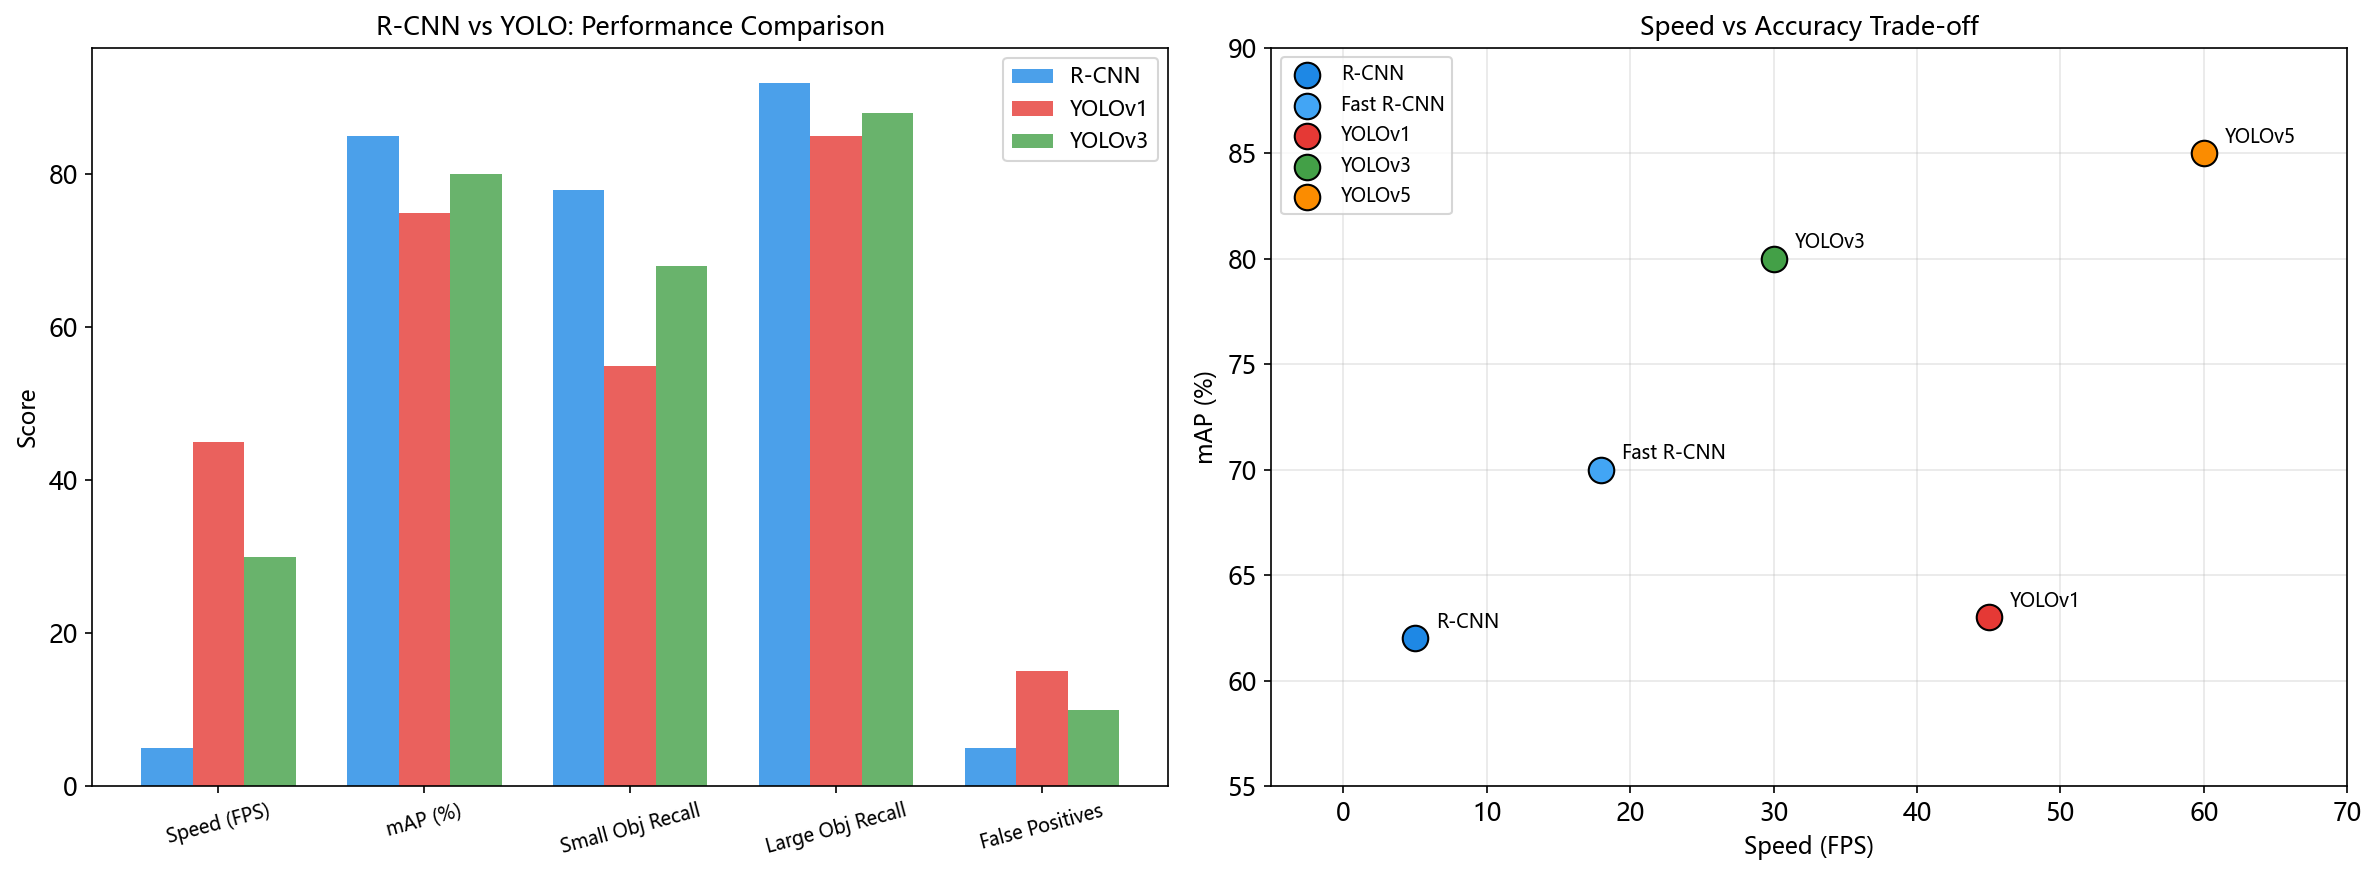

In [34]:
# Experiment 4: R-CNN vs YOLO comparison
import numpy as np
import matplotlib.pyplot as plt

# Simulate performance characteristics
categories = ['Speed (FPS)', 'mAP (%)', 'Small Obj Recall', 'Large Obj Recall', 'False Positives']
rcnn_scores = [5, 85, 78, 92, 5]  # R-CNN: slow but accurate
yolo_scores = [45, 75, 55, 85, 15]  # YOLO: fast but less accurate
yolo_v3_scores = [30, 80, 68, 88, 10]  # YOLOv3: improved

# Normalize for radar chart
max_vals = [50, 100, 100, 100, 30]
rcnn_norm = [s/m*100 for s, m in zip(rcnn_scores, max_vals)]
yolo_norm = [s/m*100 for s, m in zip(yolo_scores, max_vals)]
yolo_v3_norm = [s/m*100 for s, m in zip(yolo_v3_scores, max_vals)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparison
x = np.arange(len(categories))
width = 0.25
axes[0].bar(x - width, rcnn_scores, width, label='R-CNN', color='#1E88E5', alpha=0.8)
axes[0].bar(x, yolo_scores, width, label='YOLOv1', color='#E53935', alpha=0.8)
axes[0].bar(x + width, yolo_v3_scores, width, label='YOLOv3', color='#43A047', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, fontsize=9, rotation=15)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('R-CNN vs YOLO: Performance Comparison', fontsize=12)
axes[0].legend(fontsize=10)

# Speed vs Accuracy trade-off
speeds = [5, 0.3*60, 45, 30, 60]  # FPS
maps = [62, 70, 63, 80, 85]
labels = ['R-CNN', 'Fast R-CNN', 'YOLOv1', 'YOLOv3', 'YOLOv5']
colors = ['#1E88E5', '#42A5F5', '#E53935', '#43A047', '#FB8C00']

for sp, m, label, color in zip(speeds, maps, labels, colors):
    axes[1].scatter(sp, m, s=150, c=color, label=label, edgecolors='black', zorder=5)
    axes[1].annotate(label, (sp, m), textcoords="offset points", xytext=(10, 5), fontsize=9)

axes[1].set_xlabel('Speed (FPS)', fontsize=11)
axes[1].set_ylabel('mAP (%)', fontsize=11)
axes[1].set_title('Speed vs Accuracy Trade-off', fontsize=12)
axes[1].set_xlim(-5, 70)
axes[1].set_ylim(55, 90)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('nb8_exp_rcnn_vs_yolo.png', dpi=150)
plt.show()
print("Figure saved: nb8_exp_rcnn_vs_yolo.png")
print("\nTrade-off: More stages = higher accuracy but slower")
print("YOLO improves over versions while maintaining speed advantage")


## 4.5 检测结果可视化

**实验目的**: 将完整的检测流程可视化,展示从输入到输出的全过程。


Figure saved: nb8_exp_full_pipeline.png

Pipeline: Image -> Grid -> Raw Detections -> NMS -> Final Results
Detected 3 objects after filtering and NMS


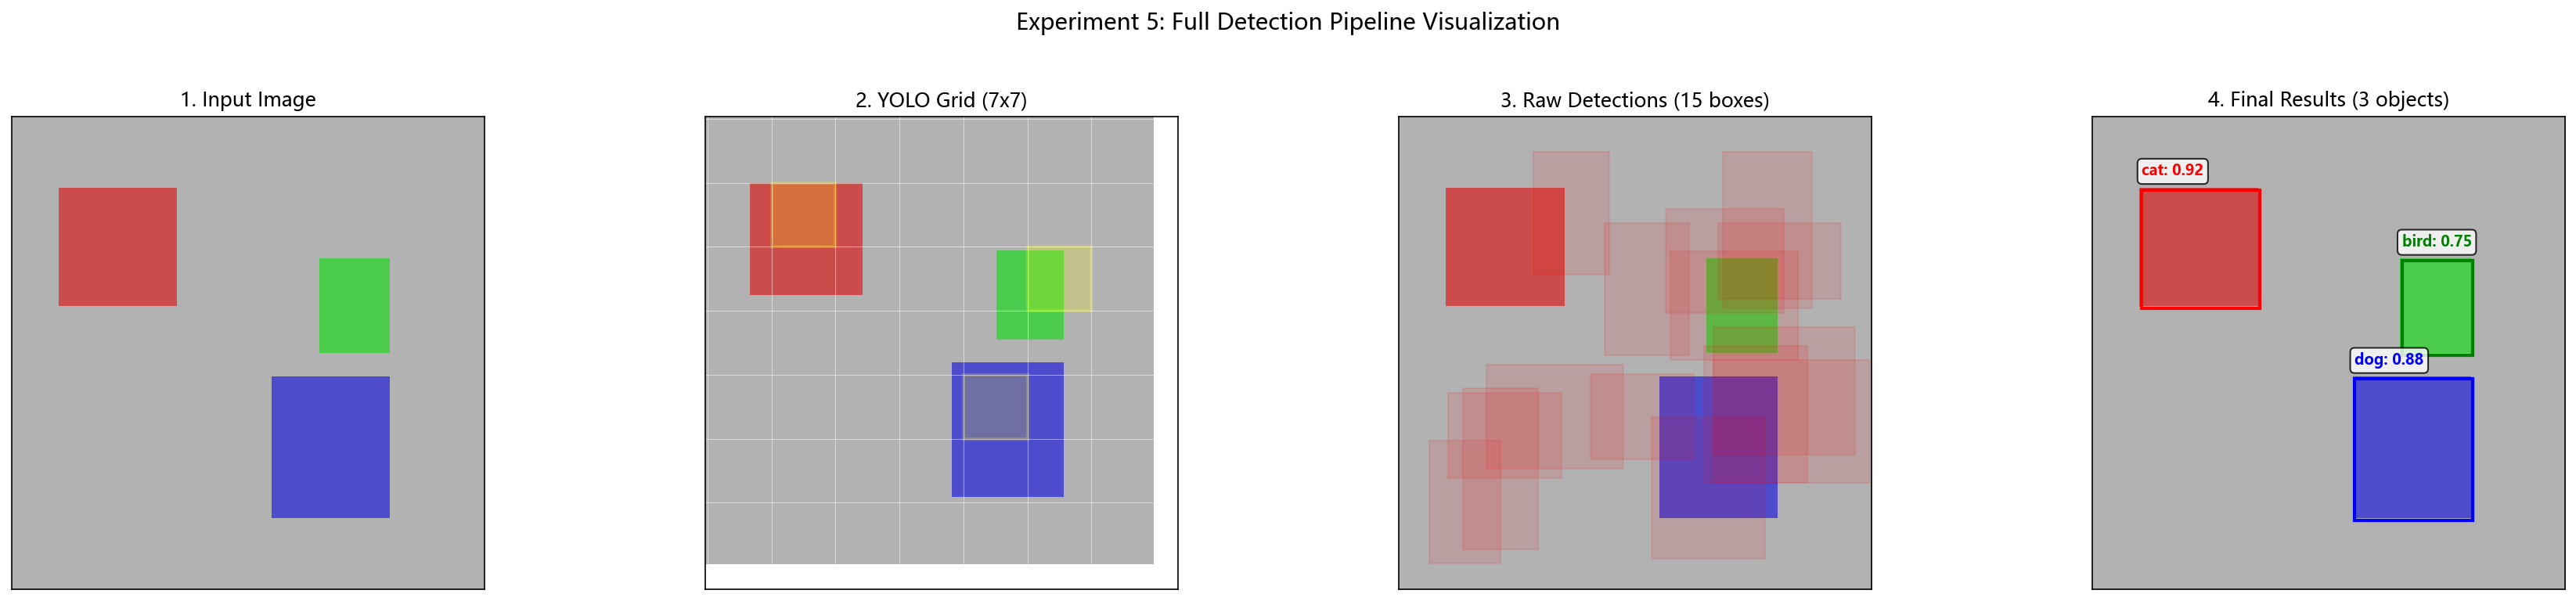

In [36]:
# Experiment 5: Full detection visualization
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

np.random.seed(42)

# Create a synthetic image with objects
img = np.ones((100, 100, 3)) * 0.7
# Object 1: cat (red)
img[15:40, 10:35] = [0.8, 0.3, 0.3]
# Object 2: dog (blue)
img[55:85, 55:80] = [0.3, 0.3, 0.8]
# Object 3: bird (green)
img[30:50, 65:80] = [0.3, 0.8, 0.3]

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Step 1: Input
axes[0].imshow(img)
axes[0].set_title('1. Input Image', fontsize=12)

# Step 2: Grid (YOLO style)
S = 7
cell = 100 / S
axes[1].imshow(img)
for i in range(S+1):
    axes[1].axhline(i*cell, color='white', linewidth=0.5, alpha=0.5)
    axes[1].axvline(i*cell, color='white', linewidth=0.5, alpha=0.5)
# Highlight cells with objects
obj_centers = [(25, 27), (67, 70), (72, 40)]
for cx, cy in obj_centers:
    gx, gy = int(cx/cell), int(cy/cell)
    rect = Rectangle((gx*cell, gy*cell), cell, cell, linewidth=2, edgecolor='yellow', facecolor='yellow', alpha=0.2)
    axes[1].add_patch(rect)
axes[1].set_title(f'2. YOLO Grid ({S}x{S})', fontsize=12)

# Step 3: Raw detections (many boxes)
axes[2].imshow(img)
np.random.seed(42)
raw_dets = []
for _ in range(15):
    x = np.random.randint(5, 70)
    y = np.random.randint(5, 70)
    w = np.random.randint(15, 35)
    h = np.random.randint(15, 35)
    score = np.random.rand()
    raw_dets.append(([x, y, x+w, y+h], score))
    rect = Rectangle((x, y), w, h, linewidth=1, edgecolor='red', facecolor='red', alpha=0.1)
    axes[2].add_patch(rect)
axes[2].set_title(f'3. Raw Detections ({len(raw_dets)} boxes)', fontsize=12)

# Step 4: Final results (after NMS)
axes[3].imshow(img)
final_dets = [
    ([10, 15, 35, 40], 'cat', 0.92),
    ([55, 55, 80, 85], 'dog', 0.88),
    ([65, 30, 80, 50], 'bird', 0.75),
]
colors = ['red', 'blue', 'green']
for (box, label, score), color in zip(final_dets, colors):
    rect = Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                      linewidth=2, edgecolor=color, facecolor='none')
    axes[3].add_patch(rect)
    axes[3].text(box[0], box[1]-3, f'{label}: {score:.2f}', color=color, fontsize=9, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[3].set_title(f'4. Final Results ({len(final_dets)} objects)', fontsize=12)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Experiment 5: Full Detection Pipeline Visualization', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb8_exp_full_pipeline.png', dpi=150)
plt.show()
print("Figure saved: nb8_exp_full_pipeline.png")
print(f"\nPipeline: Image -> Grid -> Raw Detections -> NMS -> Final Results")
print(f"Detected {len(final_dets)} objects after filtering and NMS")


---
# 实验总结

### 关键发现

1. **两阶段 vs 单阶段的核心权衡**
   - R-CNN: 高精度, 低速度, 适合离线分析
   - YOLO: 中精度, 高速度, 适合实时应用
   - 选择取决于应用场景

2. **IoU阈值是关键超参数**
   - 阈值越高, 正样本质量越高但数量越少
   - 训练用 0.7, 评估用 0.5 (COCO标准)
   - 影响anchor匹配和NMS

3. **Anchor设计影响检测覆盖率**
   - 多尺度 + 多比例 = 更好的物体覆盖
   - YOLOv2+ 使用k-means自动确定anchor尺寸
   - anchor与物体形状匹配是关键

4. **NMS是检测后处理的核心**
   - 去除重复检测, 保留最佳结果
   - 阈值选择影响精度/召回率权衡
   - Soft-NMS进一步改进处理重叠物体

### 检测系统设计原则

| 组件 | 作用 | 关键参数 |
|------|------|---------|
| Region Proposal | 生成候选区域 | 数量, 质量 |
| Anchor Boxes | 参考框 | 尺度, 比例 |
| IoU | 框匹配度量 | 阈值 |
| NMS | 去重 | IoU阈值, 置信度阈值 |
| BBox Regression | 框精修 | 回归参数编码方式 |


---
# 作业

## 作业1: 实现Soft-NMS并对比

**任务**: 实现Soft-NMS, 并与标准NMS对比。

**要求**:
1. 实现标准NMS (直接删除IoU > 阈值的框)
2. 实现Soft-NMS两种变体:
   - 线性衰减: $s_i = s_i (1 - IoU(b_{best}, b_i))$
   - 高斯衰减: $s_i = s_i \exp(-IoU^2 / \sigma)$
3. 在重叠检测场景下对比三种方法
4. 绘制: 最终保留框数量、平均置信度、mAP
5. 分析: 哪种方法在密集物体场景下更好?

**提示**: Soft-NMS不删除框, 而是降低重叠框的分数

---

## 作业2: 设计Anchor方案

**任务**: 为特定数据集设计anchor方案。

**要求**:
1. 假设检测以下5类物体:
   - 行人 (高瘦, 比例 ~1:3)
   - 汽车 (宽矮, 比例 ~2:1)
   - 交通标志 (小方形, ~1:1)
   - 自行车 (中等, ~1:1.5)
   - 卡车 (大宽, ~1.5:1)
2. 设计anchor的尺度和比例组合
3. 生成anchor并计算与各类物体GT的IoU
4. 计算每类物体的anchor覆盖率 (IoU > 0.5的比例)
5. 优化anchor方案使所有类别覆盖率 > 80%

**提交**: anchor配置 + 覆盖率统计表 + 分析

---

## 作业3: 实现mAP计算

**任务**: 实现mean Average Precision (mAP) 评估指标。

**要求**:
1. 生成模拟检测结果 (TP, FP, FN)
2. 实现Precision-Recall曲线计算
3. 实现AP (Average Precision) 计算 (11点插值)
4. 实现mAP (多类别AP的平均)
5. 在不同IoU阈值 (0.5, 0.75, 0.5:0.95) 下计算mAP
6. 可视化PR曲线

**提示**:
- TP = IoU > 阈值且类别正确的检测
- FP = IoU <= 阈值或类别错误的检测
- FN = 未被检测到的GT

**提交**: 代码 + PR曲线图 + mAP数值表


---
# 参考文献

1. **R-CNN**: Girshick, R., et al. (2014). *Rich Feature Hierarchies for Accurate Object Detection and Segmentation*. CVPR.
   - 开创两阶段检测范式, CNN + Selective Search

2. **Fast R-CNN**: Girshick, R. (2015). *Fast R-CNN*. ICCV.
   - 共享卷积特征, RoI Pooling

3. **Faster R-CNN**: Ren, S., et al. (2015). *Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks*. NeurIPS.
   - RPN替代Selective Search, Anchor Boxes

4. **YOLO**: Redmon, J., et al. (2016). *You Only Look Once: Unified, Real-Time Object Detection*. CVPR.
   - 单阶段检测, 网格划分, 实时检测

5. **YOLOv3**: Redmon, J., & Farhadi, A. (2018). *YOLOv3: An Incremental Improvement*. arXiv:1804.02767.
   - 多尺度预测, 更好的小物体检测

6. **SSD**: Liu, W., et al. (2016). *SSD: Single Shot MultiBox Detector*. ECCV.
   - 多尺度特征图, 默认框

7. **Focal Loss / RetinaNet**: Lin, T. Y., et al. (2017). *Focal Loss for Dense Object Detection*. ICCV.
   - 解决类别不平衡问题

8. **Soft-NMS**: Bodla, N., et al. (2017). *Soft-NMS -- Improving Object Detection with One Line of Code*. ICCV.

9. **CS231n Course**: Johnson, J. & Fei-Fei, L. *CS231n: Convolutional Neural Networks for Visual Recognition*. Stanford University.

---

*本notebook由CS231n课程材料启发, 所有代码实现仅使用NumPy和Matplotlib, 可独立运行。*


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[ultralytics/yolov5](https://github.com/ultralytics/yolov5)** (58006 stars): YOLOv5 官方实现（最热门检测框架）
  - 仓库地址: https://github.com/ultralytics/yolov5

- **[ultralytics/yolov3](https://github.com/ultralytics/yolov3)** (10605 stars): YOLOv3 PyTorch 实现
  - 仓库地址: https://github.com/ultralytics/yolov3

- **[lyuwenyu/RT-DETR](https://github.com/lyuwenyu/RT-DETR)** (5518 stars): RT-DETR: CVPR 2024 实时检测 Transformer
  - 仓库地址: https://github.com/lyuwenyu/RT-DETR


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

